# Test file for UNSW-NB15 model creation and analysis

### 1. Data loading

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

pd.options.display.max_rows = 80

In [2]:
import pandas as pd
import os

# read data

df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/UNSW-NB15.csv')

### 2. Data exploration

In [3]:
from IPython.display import display
display(df.head())

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,175.45.176.2-149.171.126.16-23357-80-6,175.45.176.2,23357,149.171.126.16,80,6,22/01/2015 07:50:15 AM,214392,9,21,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Exploits
1,175.45.176.0-149.171.126.16-13284-80-6,175.45.176.0,13284,149.171.126.16,80,6,22/01/2015 07:50:13 AM,2376792,9,3,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Reconnaissance
2,175.45.176.2-149.171.126.16-13792-5555-6,175.45.176.2,13792,149.171.126.16,5555,6,22/01/2015 07:50:16 AM,131350,10,3,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Exploits
3,175.45.176.0-149.171.126.15-39500-80-6,175.45.176.0,39500,149.171.126.15,80,6,22/01/2015 07:50:18 AM,164796,6,3,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DoS
4,175.45.176.0-149.171.126.14-29309-3000-6,175.45.176.0,29309,149.171.126.14,3000,6,22/01/2015 07:50:19 AM,163418,6,3,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Generic


In [4]:
print('Cantidad de Filas y columnas:',df.shape)
print('Nombre columnas:',df.columns)

Cantidad de Filas y columnas: (3540241, 84)
Nombre columnas: Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3540241 entries, 0 to 3540240
Data columns (total 84 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Flow ID                     object 
 1   Src IP                      object 
 2   Src Port                    int64  
 3   Dst IP                      object 
 4   Dst Port                    int64  
 5   Protocol                    int64  
 6   Timestamp                   object 
 7   Flow Duration               int64  
 8   Total Fwd Packet            int64  
 9   Total Bwd packets           int64  
 10  Total Length of Fwd Packet  float64
 11  Total Length of Bwd Packet  float64
 12  Fwd Packet Length Max       float64
 13  Fwd Packet Length Min       float64
 14  Fwd Packet Length Mean      float64
 15  Fwd Packet Length Std       float64
 16  Bwd Packet Length Max       float64
 17  Bwd Packet Length Min       float64
 18  Bwd Packet Length Mean      float64
 19  Bwd Packet Length Std

In [6]:
# parse Label to string
df['Label'] = df['Label'].astype(str)

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Src Port,3540241.0,31875.725738,1.948902e+04,10.000000,14729.000000,31789.000000,48846.000000,6.553500e+04
Dst Port,3540241.0,16416.323047,2.038958e+04,10.000000,80.000000,6434.000000,30906.000000,6.553500e+04
Protocol,3540241.0,7.759312,4.032029e+00,6.000000,6.000000,6.000000,6.000000,1.700000e+01
Flow Duration,3540241.0,348760.158138,2.748282e+06,1.000000,343.000000,1229.000000,52351.000000,1.199995e+08
Total Fwd Packet,3540241.0,22.661563,6.852967e+01,1.000000,1.000000,2.000000,22.000000,2.003800e+04
Total Bwd packets,3540241.0,29.387113,1.010743e+02,0.000000,2.000000,2.000000,23.000000,1.102100e+04
Total Length of Fwd Packet,3540241.0,1878.353584,5.530137e+04,0.000000,0.000000,90.000000,474.000000,2.605270e+07
Total Length of Bwd Packet,3540241.0,23421.268448,1.282813e+05,0.000000,0.000000,122.000000,4986.000000,1.421599e+07
Fwd Packet Length Max,3540241.0,150.079726,3.216338e+02,0.000000,0.000000,45.000000,114.000000,1.476000e+03
Fwd Packet Length Min,3540241.0,10.940842,3.996782e+01,0.000000,0.000000,0.000000,0.000000,1.472000e+03


### 3. Data cleaning

In [7]:
# Duplicate values
duplicates = df.duplicated()
print(f'There are {duplicates.sum()} duplicated rows in the dataset. Total shape: {df.shape}')


There are 59906 duplicated rows in the dataset. Total shape: (3540241, 84)


In [8]:
df.drop_duplicates(inplace=True)
print(f'Duplicated rows have been removed. New shape: {df.shape}')

Duplicated rows have been removed. New shape: (3480335, 84)


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Series([], dtype: int64)


In [10]:
# Checking for infinity values
numeric_cols = df.select_dtypes(include = np.number).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Series([], dtype: int64)


In [11]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {df.isna().sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {df.isna().sum().sum()}')

missing = df.isna().sum()
print(missing.loc[missing > 0])

Initial missing values: 0
Missing values after processing infinite values: 0
Series([], dtype: int64)


In [12]:
# Calculating missing value percentage in the dataset
mis_per = (missing / len(df)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

Empty DataFrame
Columns: [Missing Values, Percentage of Total Values]
Index: []


In [13]:
med_flow_bytes = df['Flow Bytes/s'].median()
med_flow_packets = df['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  9508.394242703576
Median of Flow Packets/s:  4427.034423546457


In [14]:
# Filling missing values with median
df['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
df['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

print('Number of \'Flow Bytes/s\' missing values:', df['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', df['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


/tmp/ipykernel_30080/4078083560.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
/tmp/ipykernel_30080/4078083560.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [15]:
# save clean dataset
df.to_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/UNSW-NB15_clean.csv', index=False)

### 4. Data visualization


In [16]:
df['Label'].value_counts()

Label
Benign            3390752
Exploits            30951
Fuzzers             29613
Reconnaissance      16735
Generic              4632
DoS                  4467
Shellcode            2102
Backdoor              452
Analysis              385
Worms                 246
Name: count, dtype: int64

In [17]:
# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df['Attack Type'] = df['Label']
df['Attack Type'].value_counts()
df.drop('Label', axis = 1, inplace = True)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])

encoded_values = df['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

0: Analysis
1: Backdoor
2: Benign
3: DoS
4: Exploits
5: Fuzzers
6: Generic
7: Reconnaissance
8: Shellcode
9: Worms


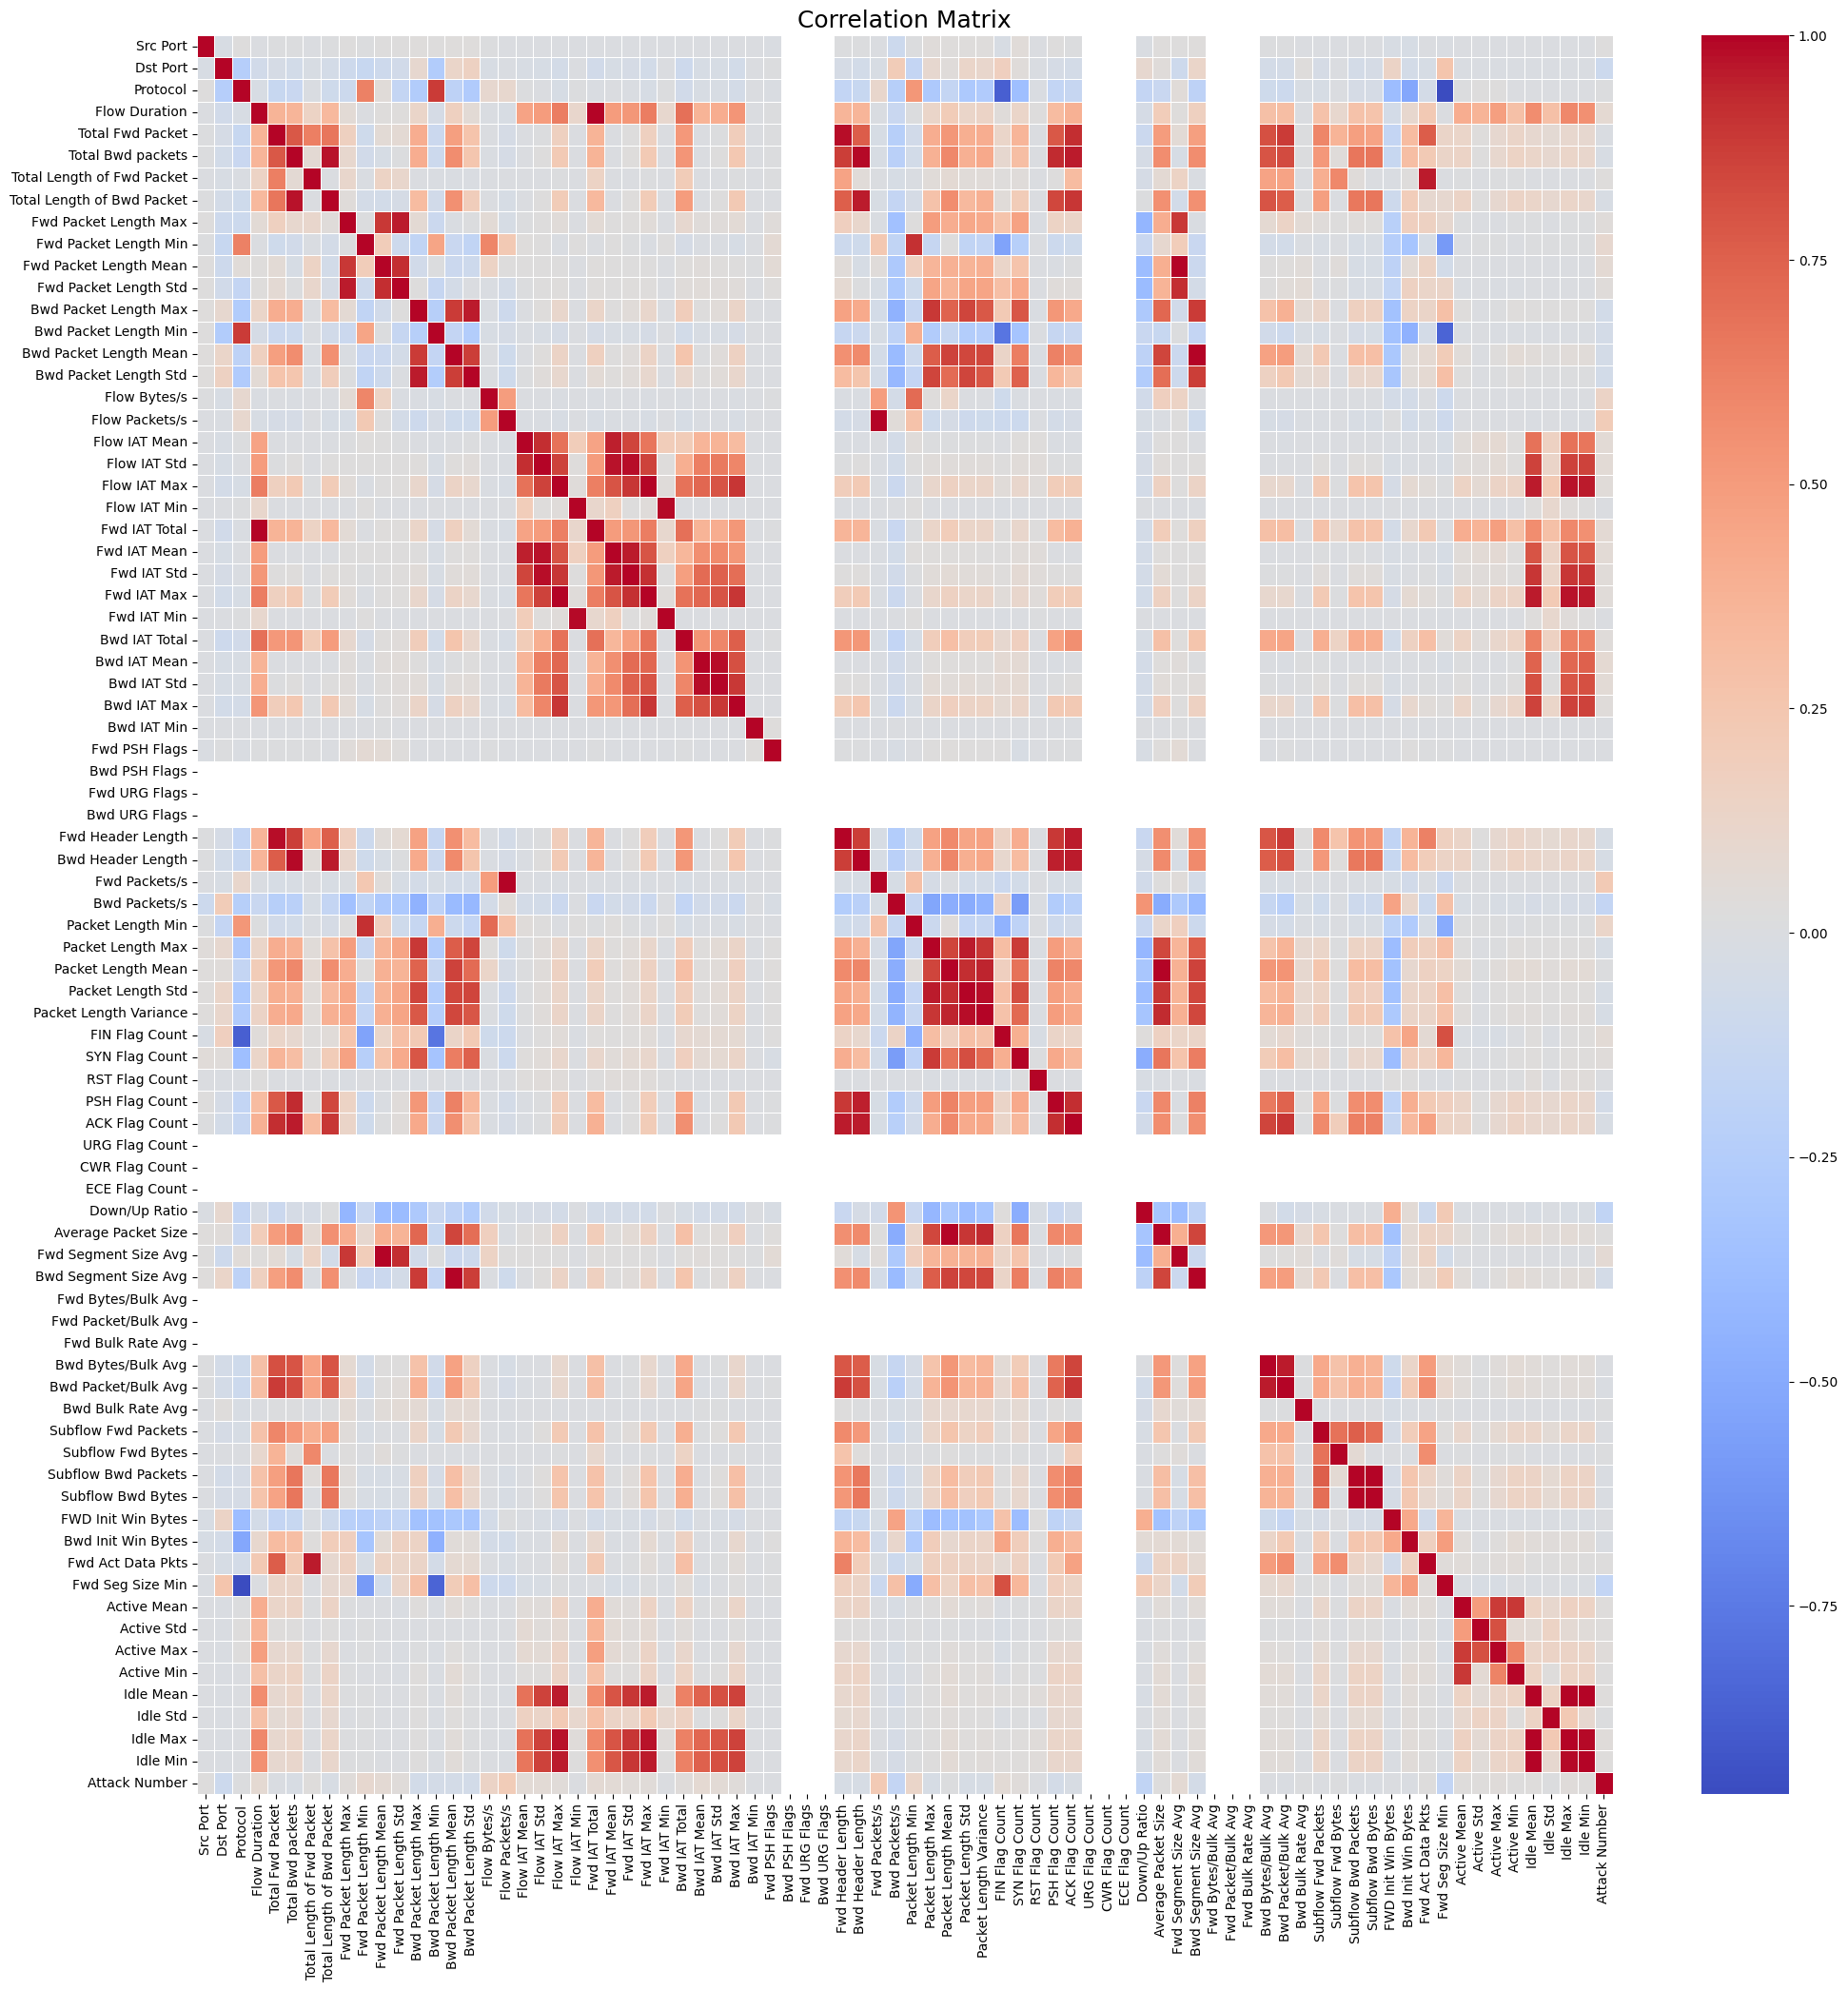

In [20]:
corr = df.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

fig, ax = plt.subplots(figsize = (24, 24))
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [21]:
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()
# ordenador por valor absoluto
pos_corr_features.sort(key = lambda x: abs(corr.loc[x, 'Attack Number']), reverse = True)

print("Features with positive correlation with 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

print(f'Number of considerable important features: {len(pos_corr_features)}')

Features with positive correlation with 'Attack Number':

1.  Fwd Packets/s            :0.22
2.  Flow Packets/s           :0.21
3.  Flow Bytes/s             :0.14
4.  Packet Length Min        :0.12
5.  Fwd Packet Length Min    :0.09
6.  Flow Duration            :0.08
7.  Bwd IAT Mean             :0.08
8.  Fwd Packet Length Mean   :0.07
9.  Fwd IAT Total            :0.07
10. Fwd Segment Size Avg     :0.07
11. Flow IAT Mean            :0.06
12. Flow IAT Std             :0.06
13. Fwd IAT Mean             :0.06
14. Bwd IAT Std              :0.06
15. FIN Flag Count           :0.06
16. Flow IAT Max             :0.05
17. Fwd IAT Std              :0.05
18. Fwd IAT Max              :0.05
19. Fwd Packet Length Max    :0.04
20. Fwd Packet Length Std    :0.04
21. Bwd IAT Total            :0.04
22. Bwd IAT Max              :0.04
23. SYN Flag Count           :0.04
24. Active Max               :0.04
25. Idle Max                 :0.04
26. Total Length of Fwd Packet :0.03
27. Active Mean              :

In [22]:
# Identifying outliers
numeric_data = df.select_dtypes(include = ['float', 'int'])
q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
iqr = q3 - q1
outlier = (numeric_data < (q1 - 1.5 * iqr)) | (numeric_data > (q3 + 1.5 * iqr))
outlier_count = outlier.sum()
outlier_percentage = round(outlier.mean() * 100, 2)
outlier_stats = pd.concat([outlier_count, outlier_percentage], axis = 1)
outlier_stats.columns = ['Outlier Count', 'Outlier Percentage']

print(outlier_stats)

                            Outlier Count  Outlier Percentage
Src Port                                0                0.00
Dst Port                                0                0.00
Protocol                           555985               15.98
Flow Duration                      665772               19.13
Total Fwd Packet                   357584               10.27
Total Bwd packets                  356041               10.23
Total Length of Fwd Packet         382766               11.00
Total Length of Bwd Packet         602238               17.30
Fwd Packet Length Max              322233                9.26
Fwd Packet Length Min              556675               15.99
Fwd Packet Length Mean             325384                9.35
Fwd Packet Length Std              656276               18.86
Bwd Packet Length Max                   0                0.00
Bwd Packet Length Min              534070               15.35
Bwd Packet Length Mean             732427               21.04
Bwd Pack

In [23]:
# Identifying outliers based on attack type
outlier_counts = {}
for i in numeric_data:
    for attack_type in df['Attack Type'].unique():
        attack_data = df[i][df['Attack Type'] == attack_type]
        q1, q3 = np.percentile(attack_data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        num_outliers = ((attack_data < lower_bound) | (attack_data > upper_bound)).sum()
        outlier_percent = num_outliers / len(attack_data) * 100
        outlier_counts[(i, attack_type)] = (num_outliers, outlier_percent)

for i in numeric_data:
  print(f'Feature: {i}')
  for attack_type in df['Attack Type'].unique():
    num_outliers, outlier_percent = outlier_counts[(i, attack_type)]
    print(f'- {attack_type}: {num_outliers} ({outlier_percent:.2f}%)')
  print()

Feature: Src Port
- Exploits: 0 (0.00%)
- Reconnaissance: 0 (0.00%)
- DoS: 0 (0.00%)
- Generic: 0 (0.00%)
- Benign: 0 (0.00%)
- Shellcode: 0 (0.00%)
- Fuzzers: 0 (0.00%)
- Worms: 0 (0.00%)
- Backdoor: 0 (0.00%)
- Analysis: 0 (0.00%)

Feature: Dst Port
- Exploits: 6645 (21.47%)
- Reconnaissance: 3862 (23.08%)
- DoS: 836 (18.72%)
- Generic: 967 (20.88%)
- Benign: 0 (0.00%)
- Shellcode: 0 (0.00%)
- Fuzzers: 2720 (9.19%)
- Worms: 21 (8.54%)
- Backdoor: 12 (2.65%)
- Analysis: 6 (1.56%)

Feature: Protocol
- Exploits: 601 (1.94%)
- Reconnaissance: 0 (0.00%)
- DoS: 406 (9.09%)
- Generic: 1143 (24.68%)
- Benign: 542811 (16.01%)
- Shellcode: 0 (0.00%)
- Fuzzers: 5398 (18.23%)
- Worms: 21 (8.54%)
- Backdoor: 34 (7.52%)
- Analysis: 0 (0.00%)

Feature: Flow Duration
- Exploits: 2398 (7.75%)
- Reconnaissance: 603 (3.60%)
- DoS: 414 (9.27%)
- Generic: 659 (14.23%)
- Benign: 633949 (18.70%)
- Shellcode: 204 (9.71%)
- Fuzzers: 1801 (6.08%)
- Worms: 30 (12.20%)
- Backdoor: 39 (8.63%)
- Analysis: 25 (6.4

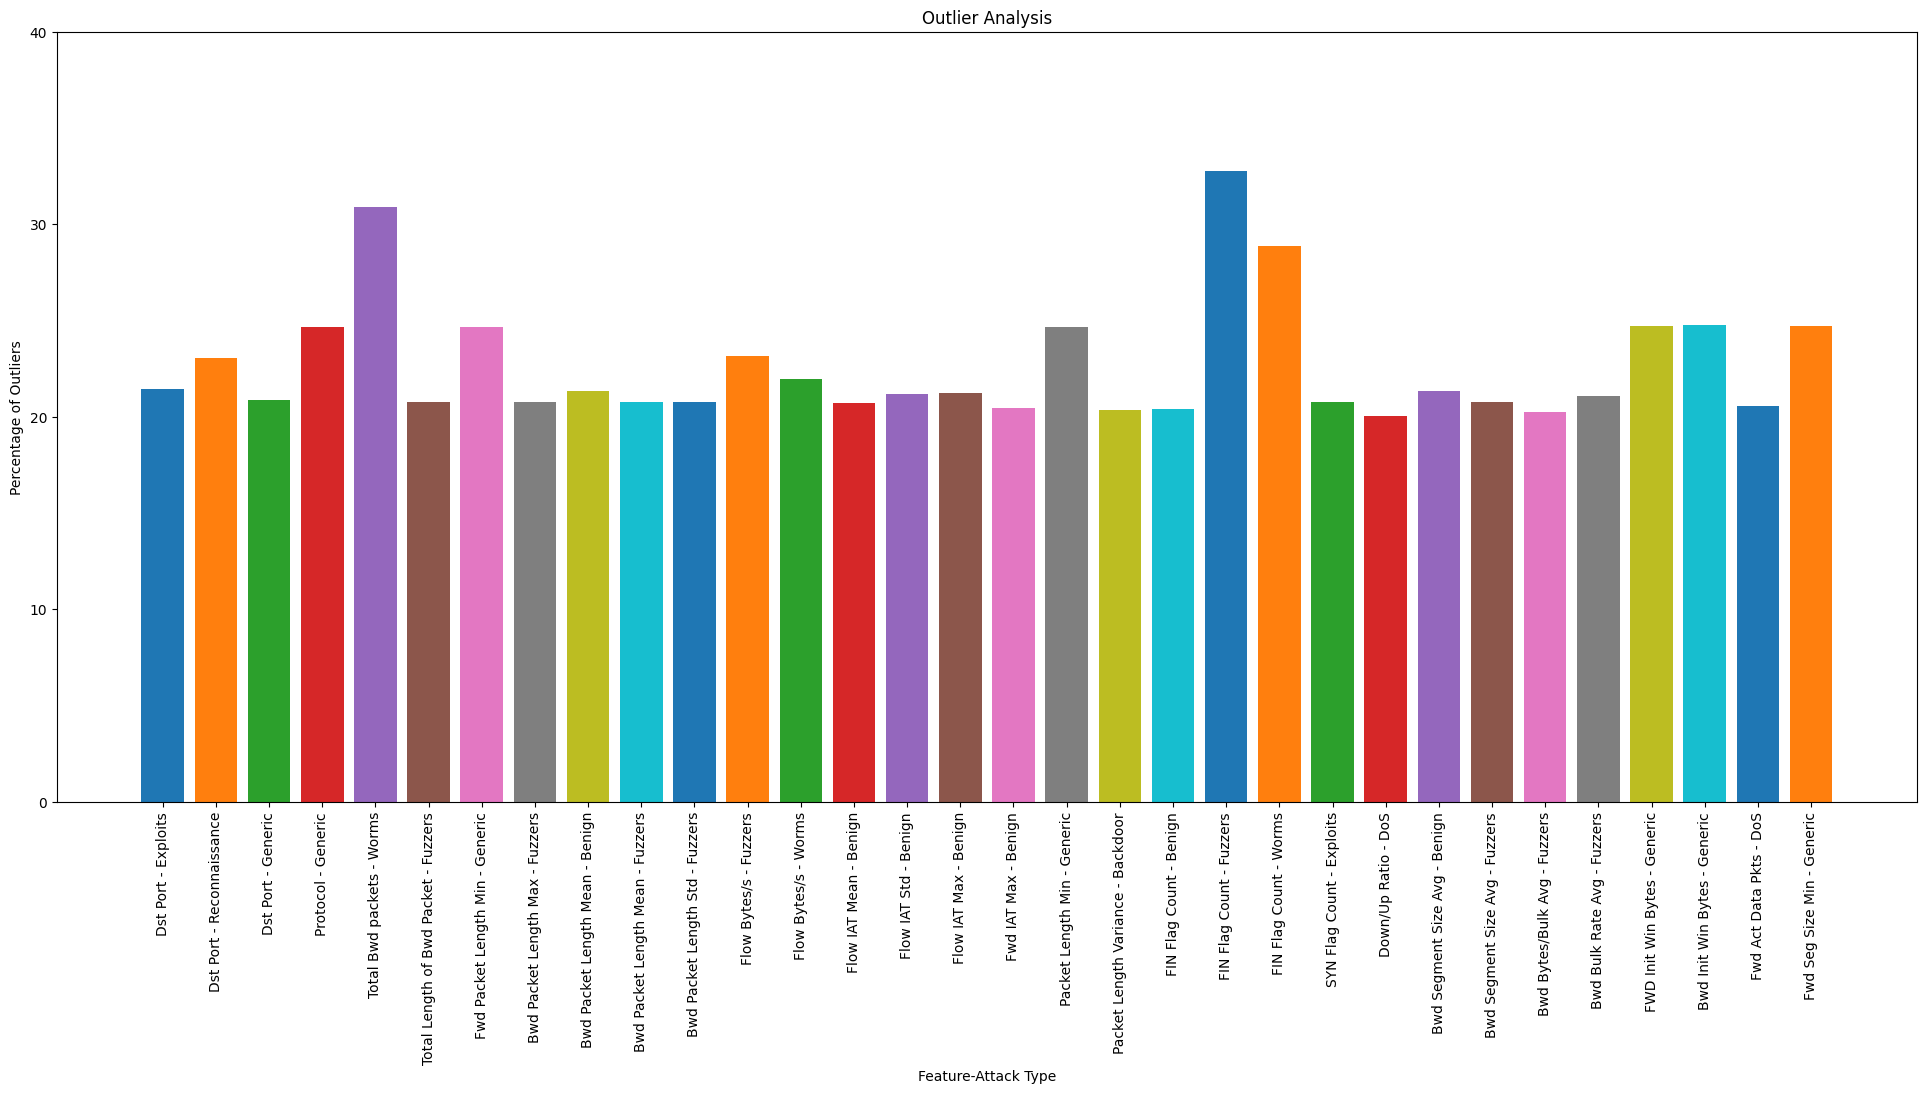

In [24]:
# Plotting the percentage of outliers that are higher than 20%
fig, ax = plt.subplots(figsize = (24, 10))
for i in numeric_data:
    for attack_type in df['Attack Type'].unique():
        num_outliers, outlier_percent = outlier_counts[(i, attack_type)]
        if outlier_percent > 20:
            ax.bar(f'{i} - {attack_type}', outlier_percent)

ax.set_xlabel('Feature-Attack Type')
ax.set_ylabel('Percentage of Outliers')
ax.set_title('Outlier Analysis')
ax.set_yticks(np.arange(0, 41, 10))
plt.xticks(rotation = 90)
plt.show()

/tmp/ipykernel_2705846/1517661817.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)


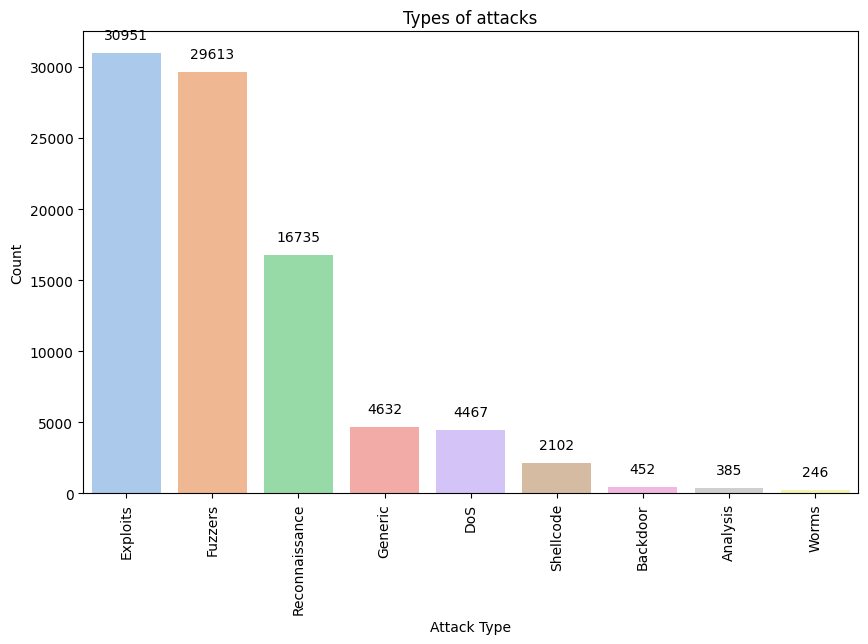

In [25]:
# Different 'Attack Type' in the main dataset excluding 'BENIGN'
attacks = df.loc[df['Attack Type'] != 'Benign']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

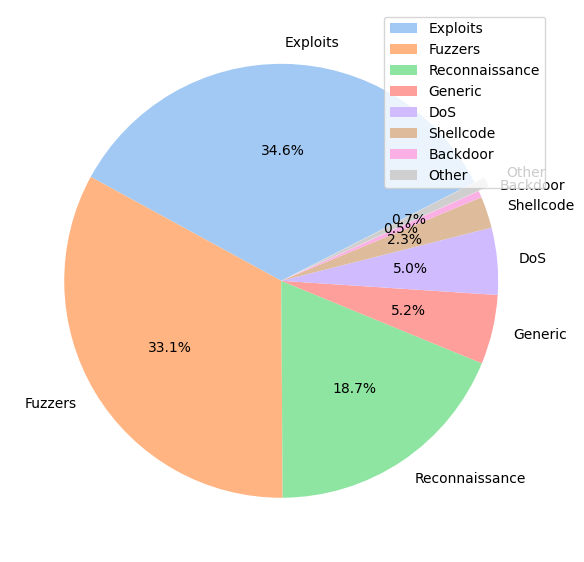

In [26]:
# Calculate attack type distribution
attack_counts = attacks['Attack Type'].value_counts()
threshold = 0.005
percentages = attack_counts / attack_counts.sum()
small_slices = percentages[percentages < threshold].index.tolist()

# Combine small categories into 'Other'
if small_slices:
    other_sum = attack_counts[small_slices].sum()
    attack_counts = attack_counts.drop(small_slices)
    attack_counts['Other'] = other_sum

# Plot settings
sns.set_palette('pastel')
plt.figure(figsize=(6,6))

# Improved labels with clearer formatting
explode = [0.05 if label == 'Other' else 0 for label in attack_counts.index]
plt.pie(
    attack_counts.values, 
    labels=attack_counts.index, 
    autopct='%1.1f%%', 
    textprops={'fontsize': 10},
    explode=explode,
    startangle=387
)

# Title and legend adjustments
plt.legend(attack_counts.index, loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('attack_distribution.png',dpi=500)
plt.show()


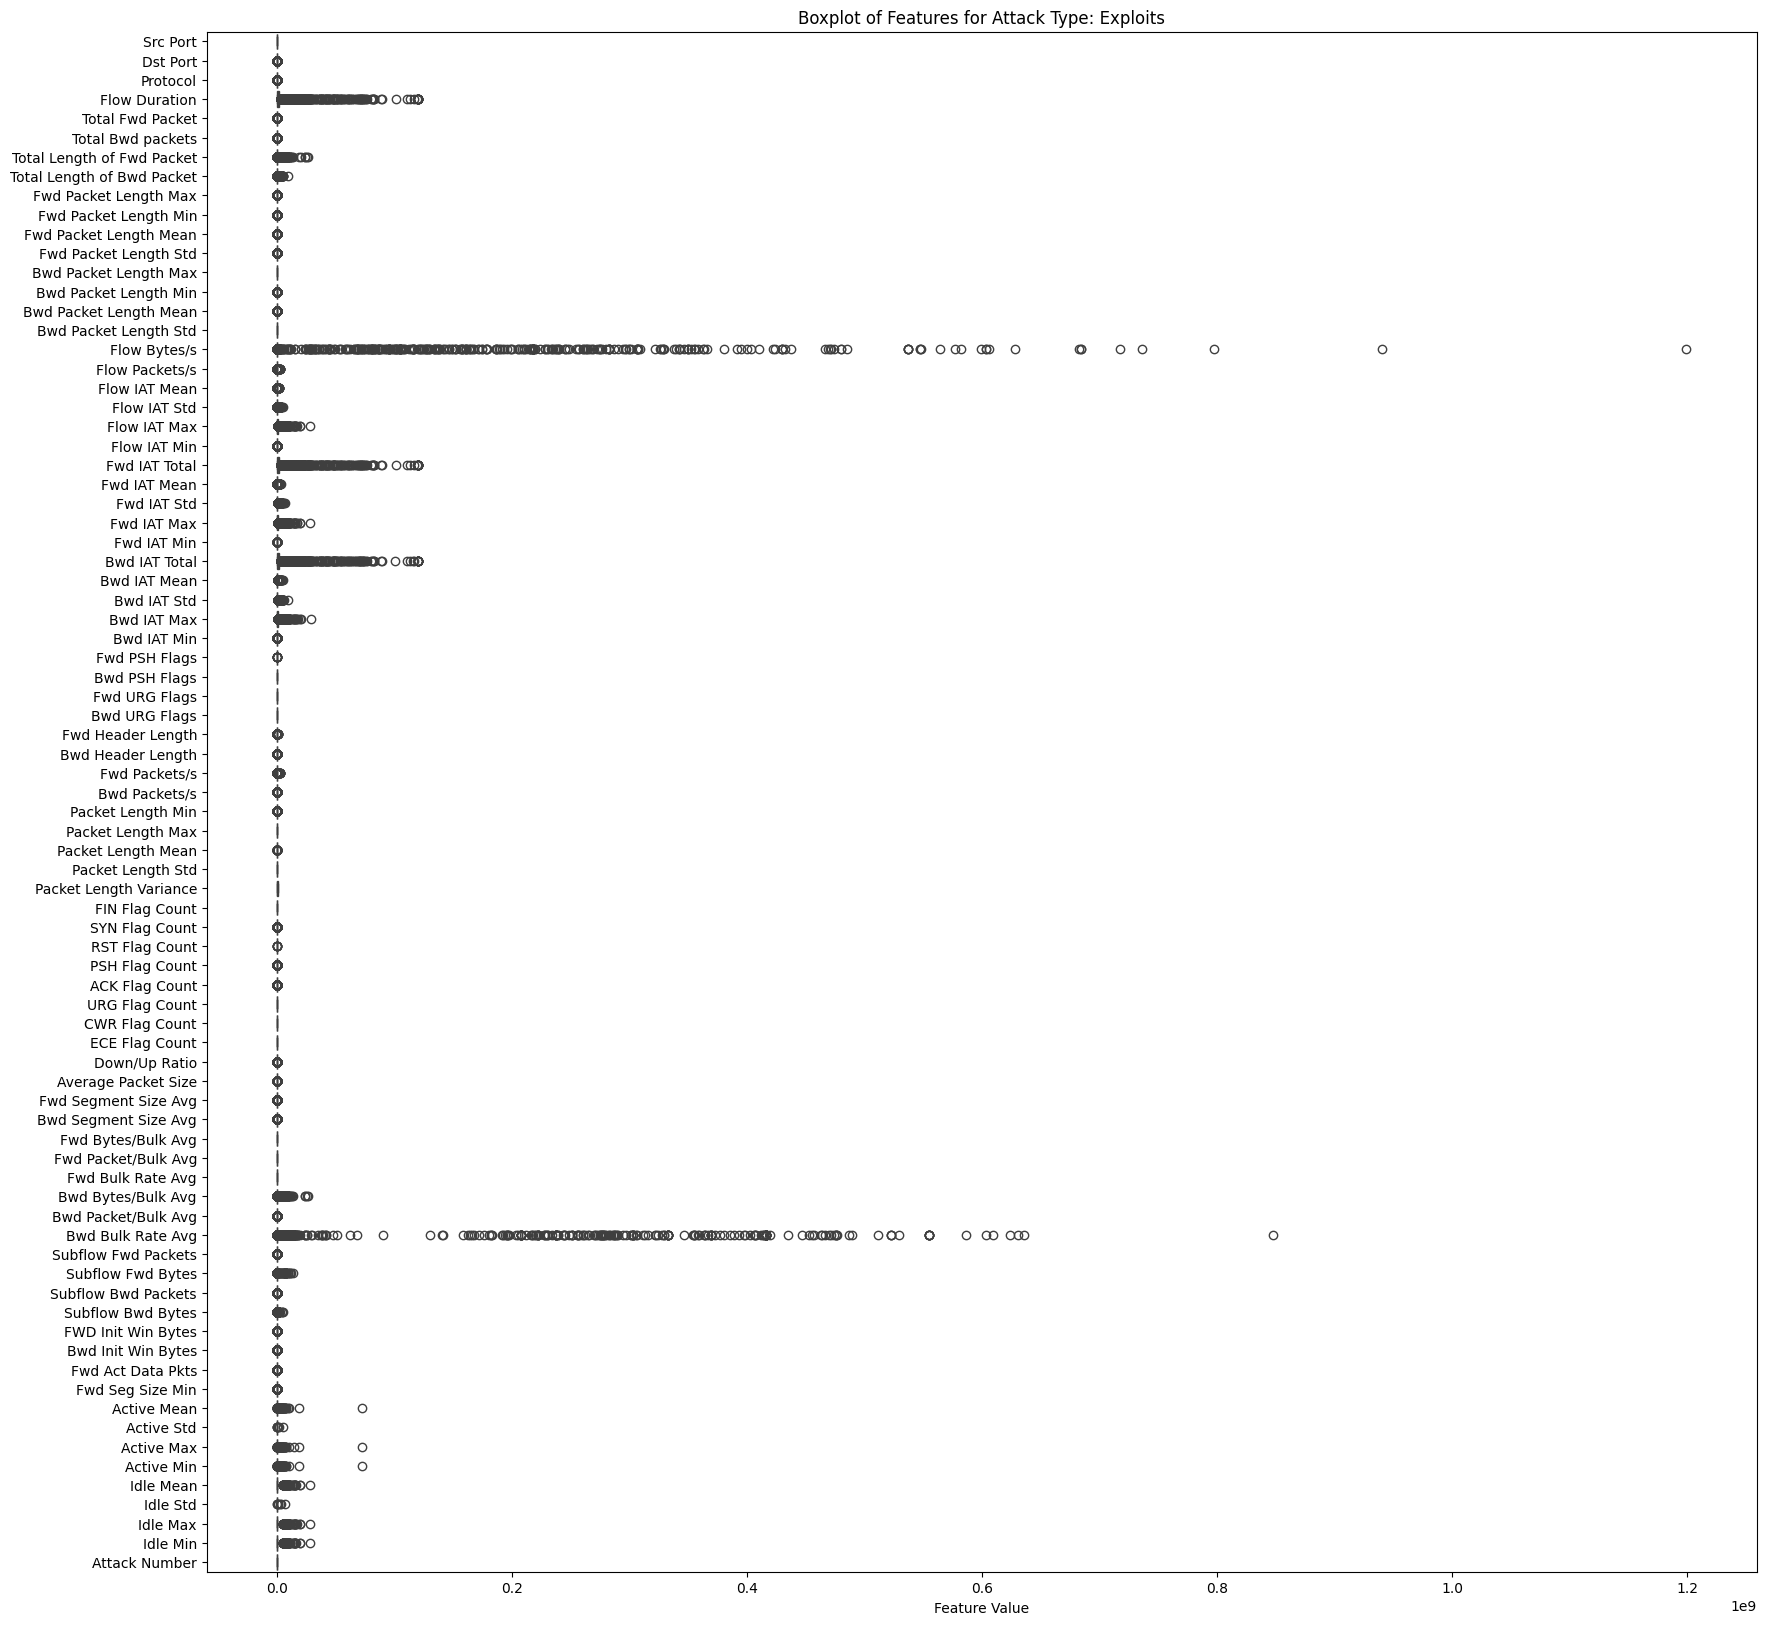

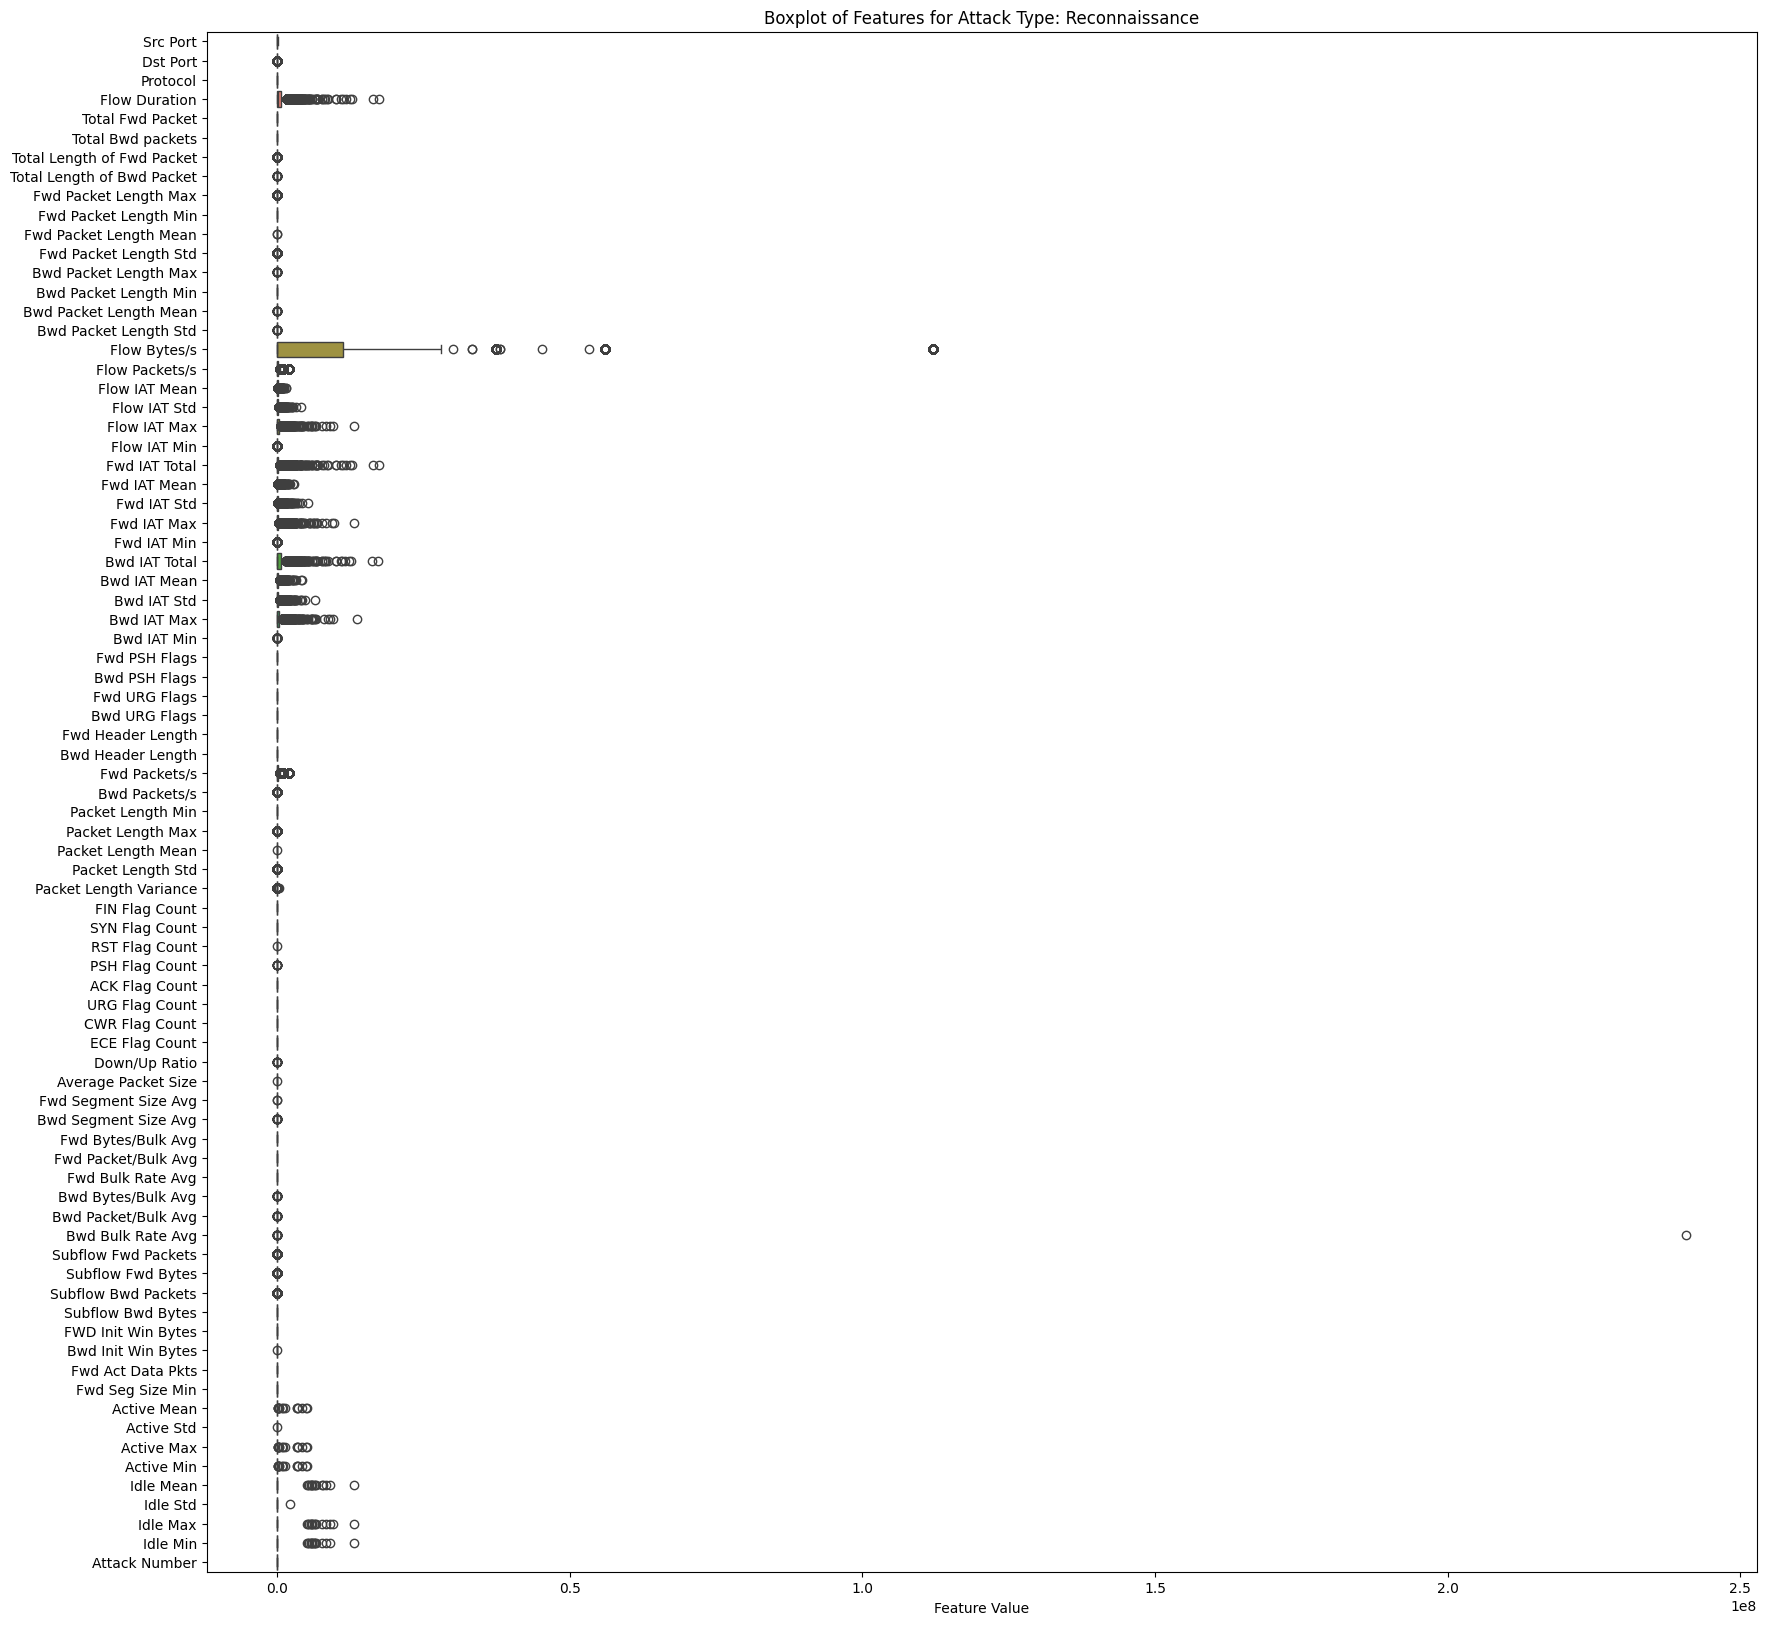

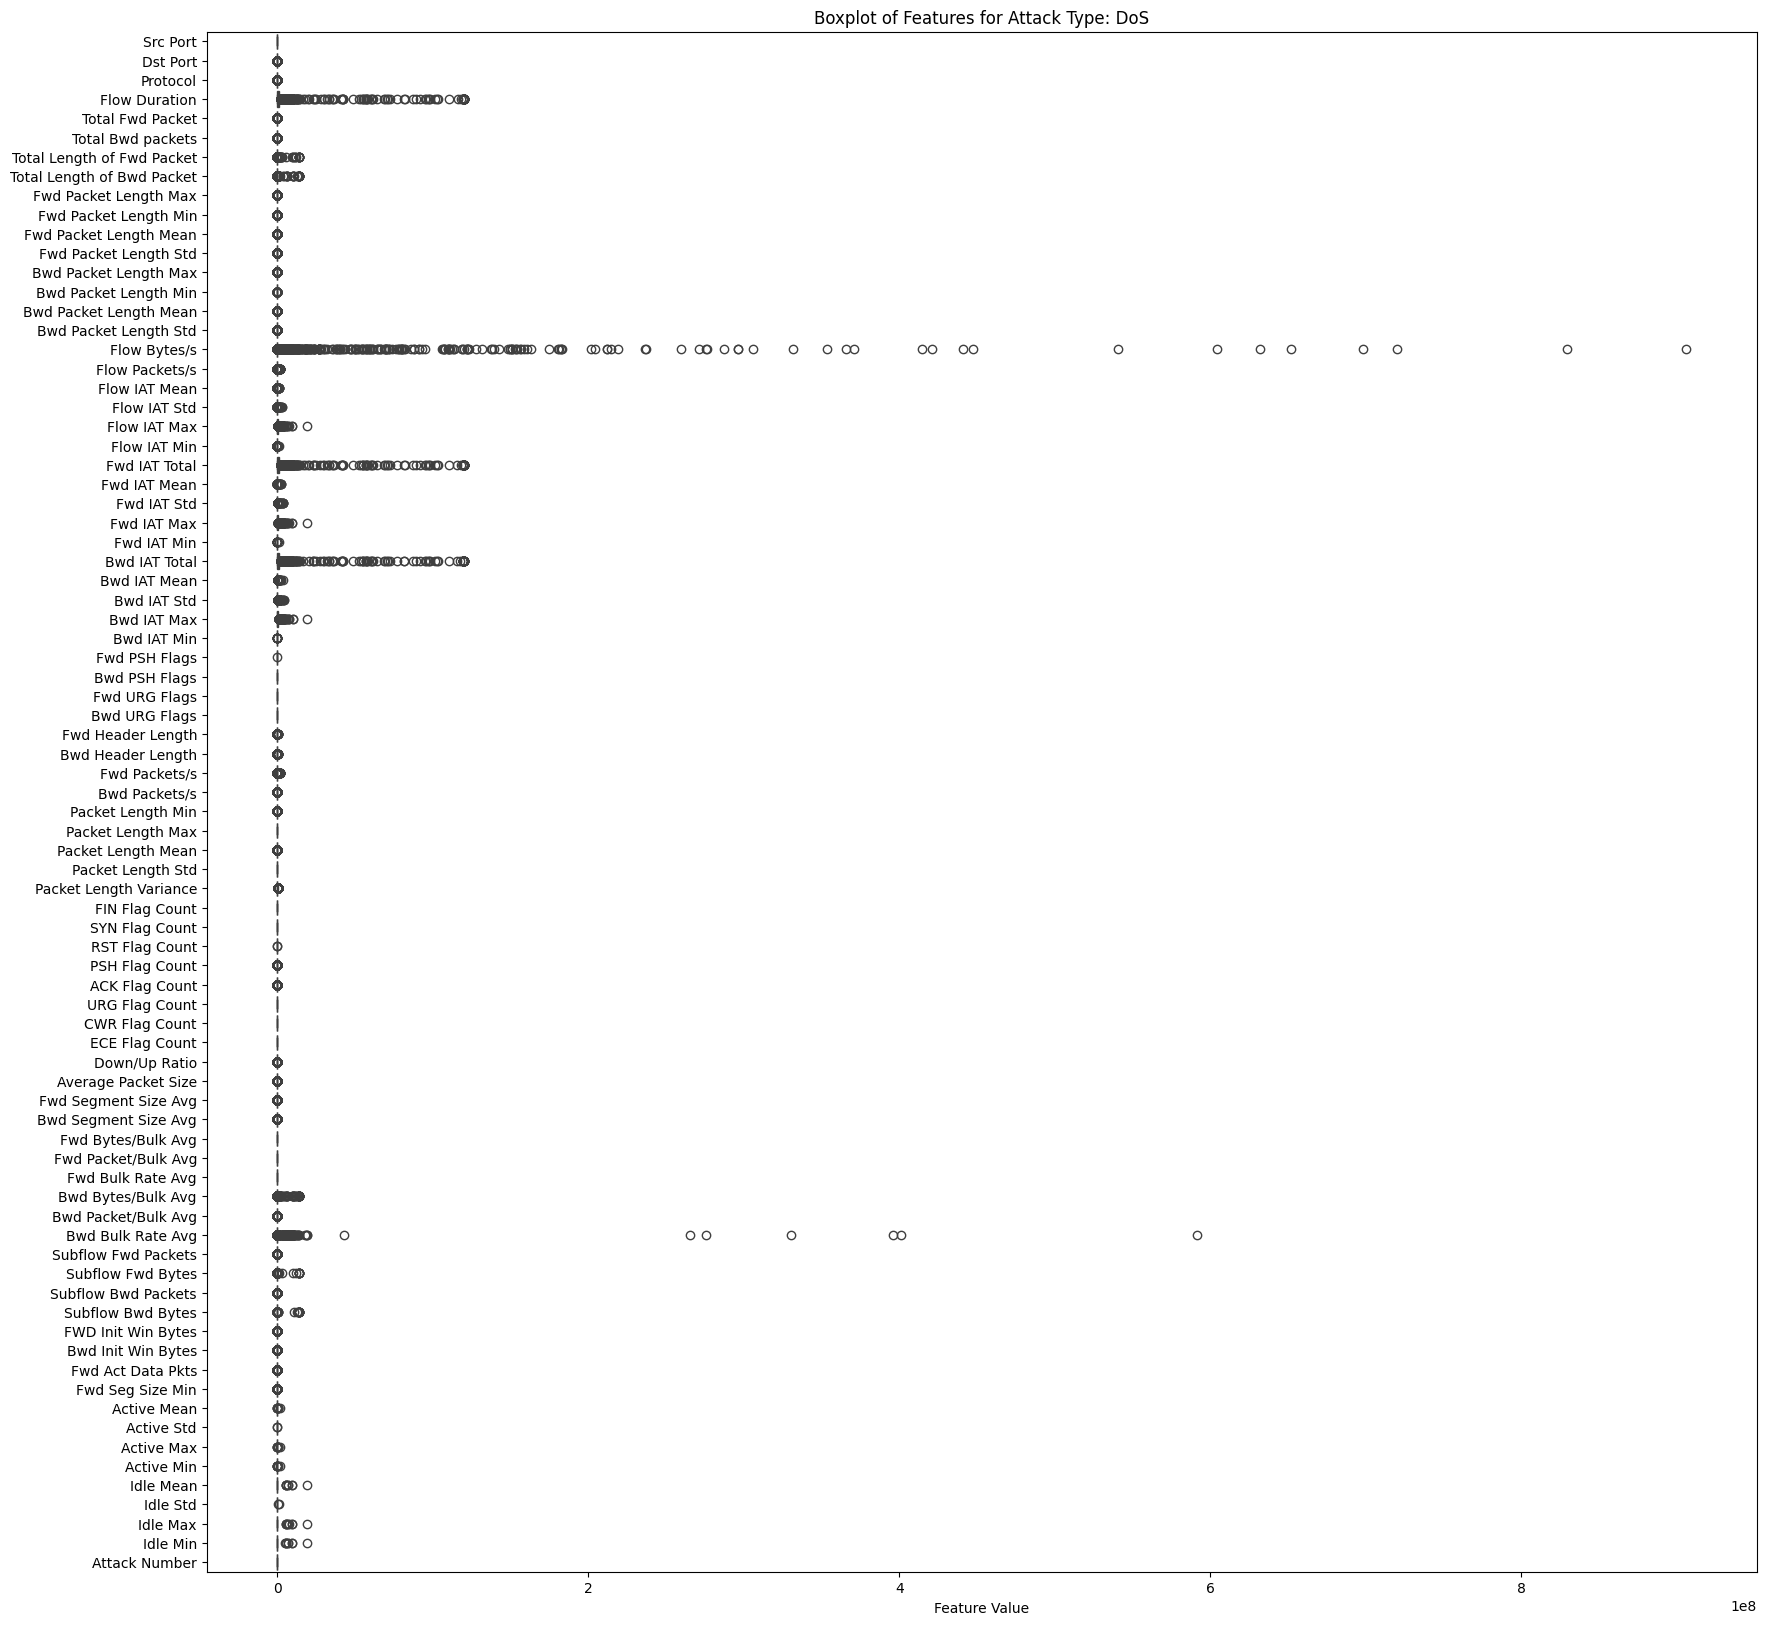

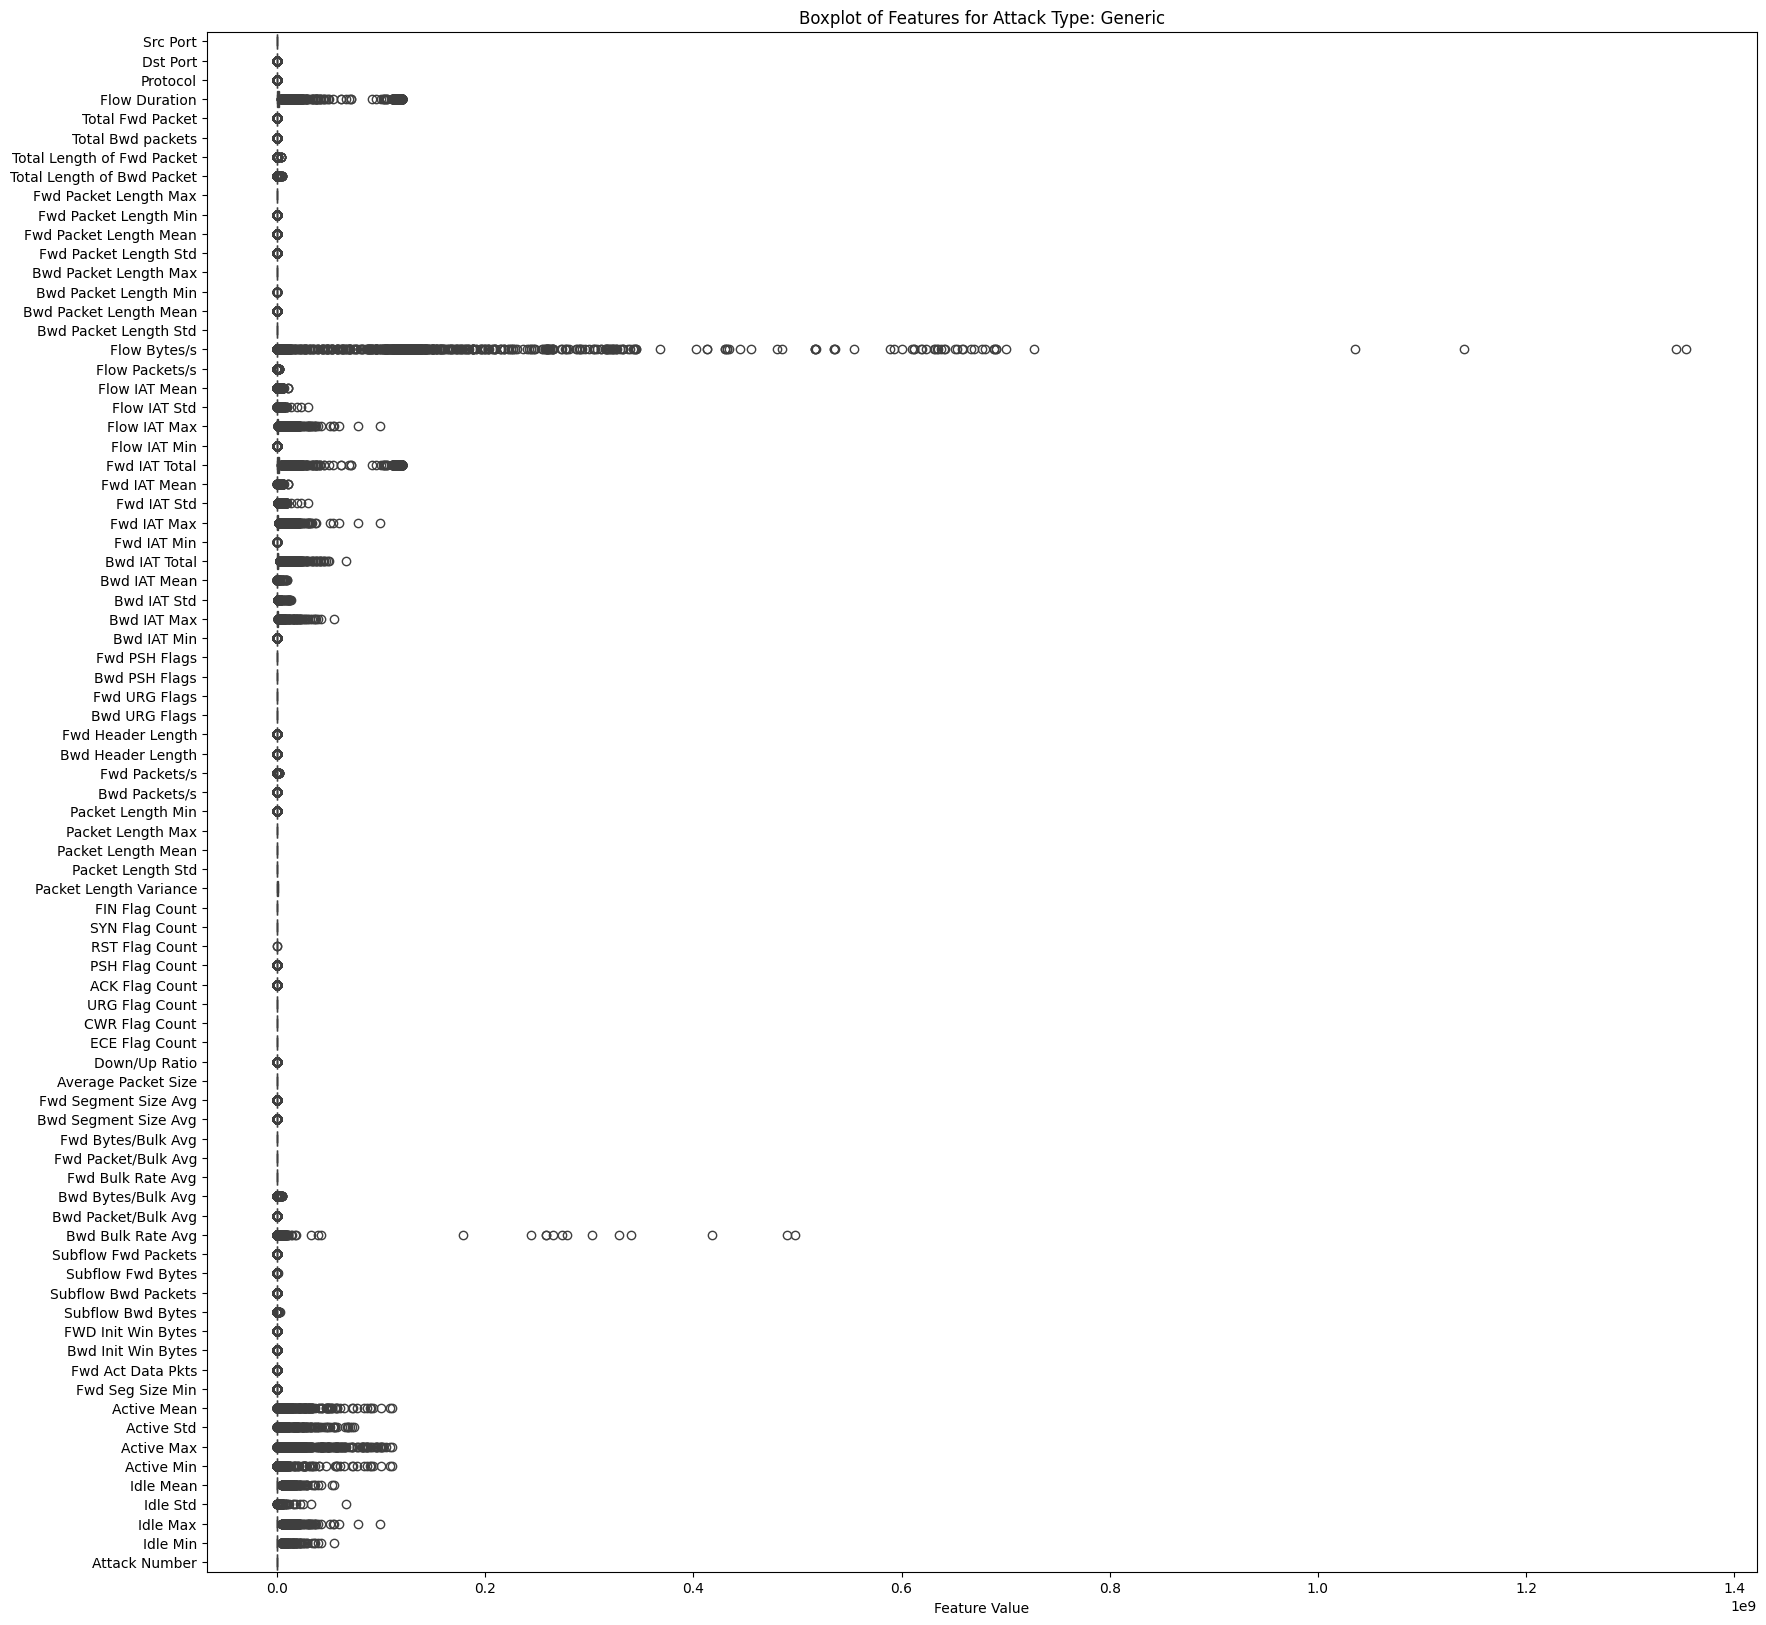

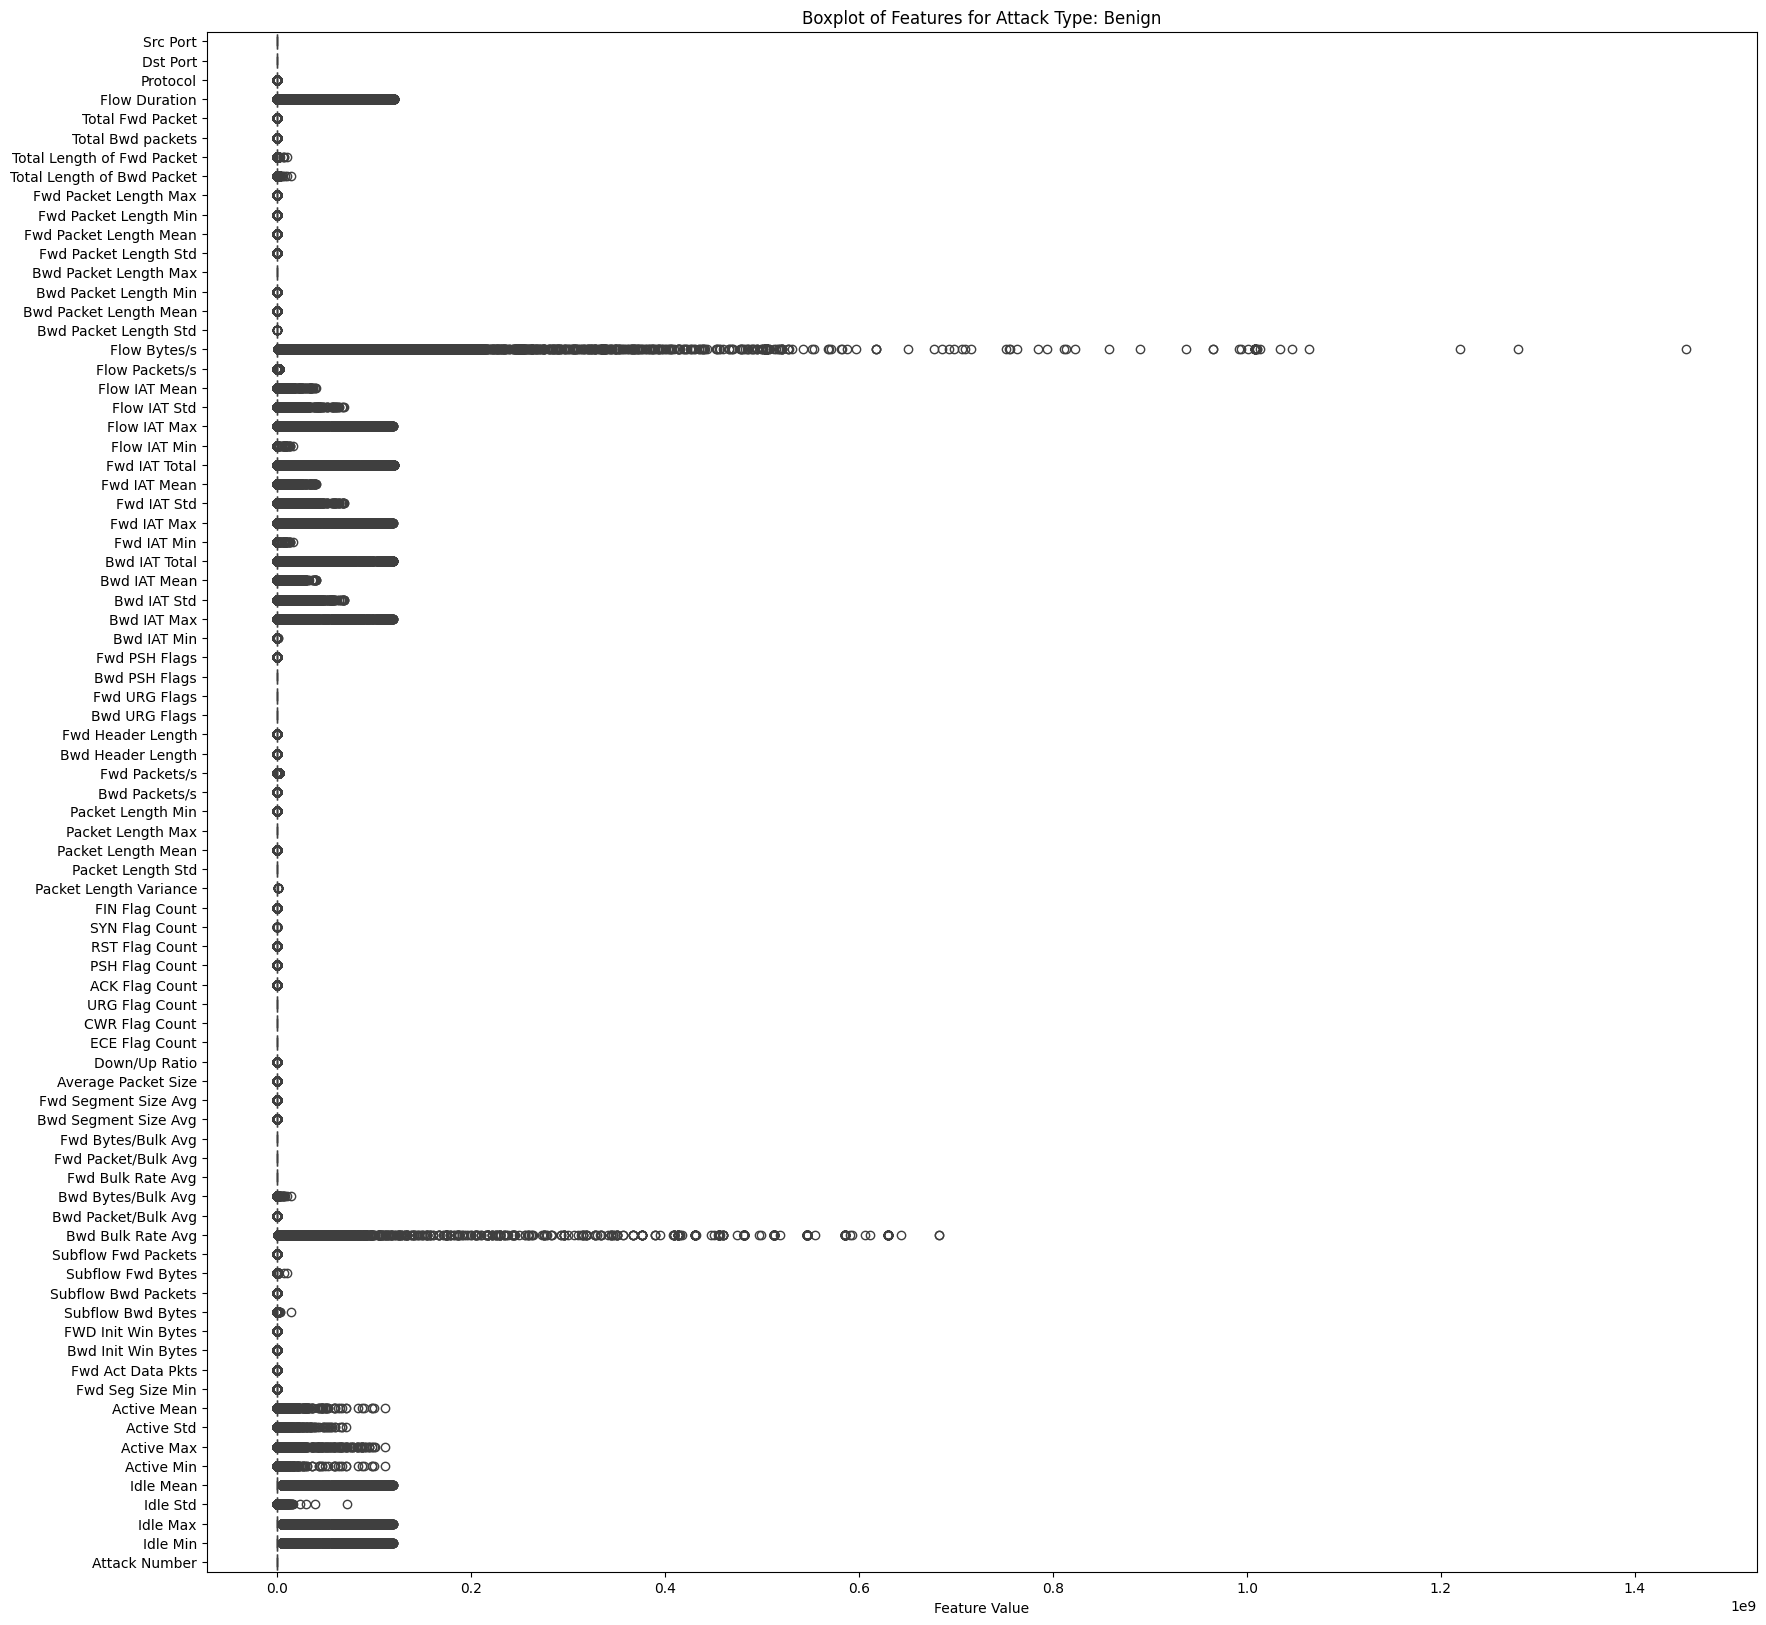

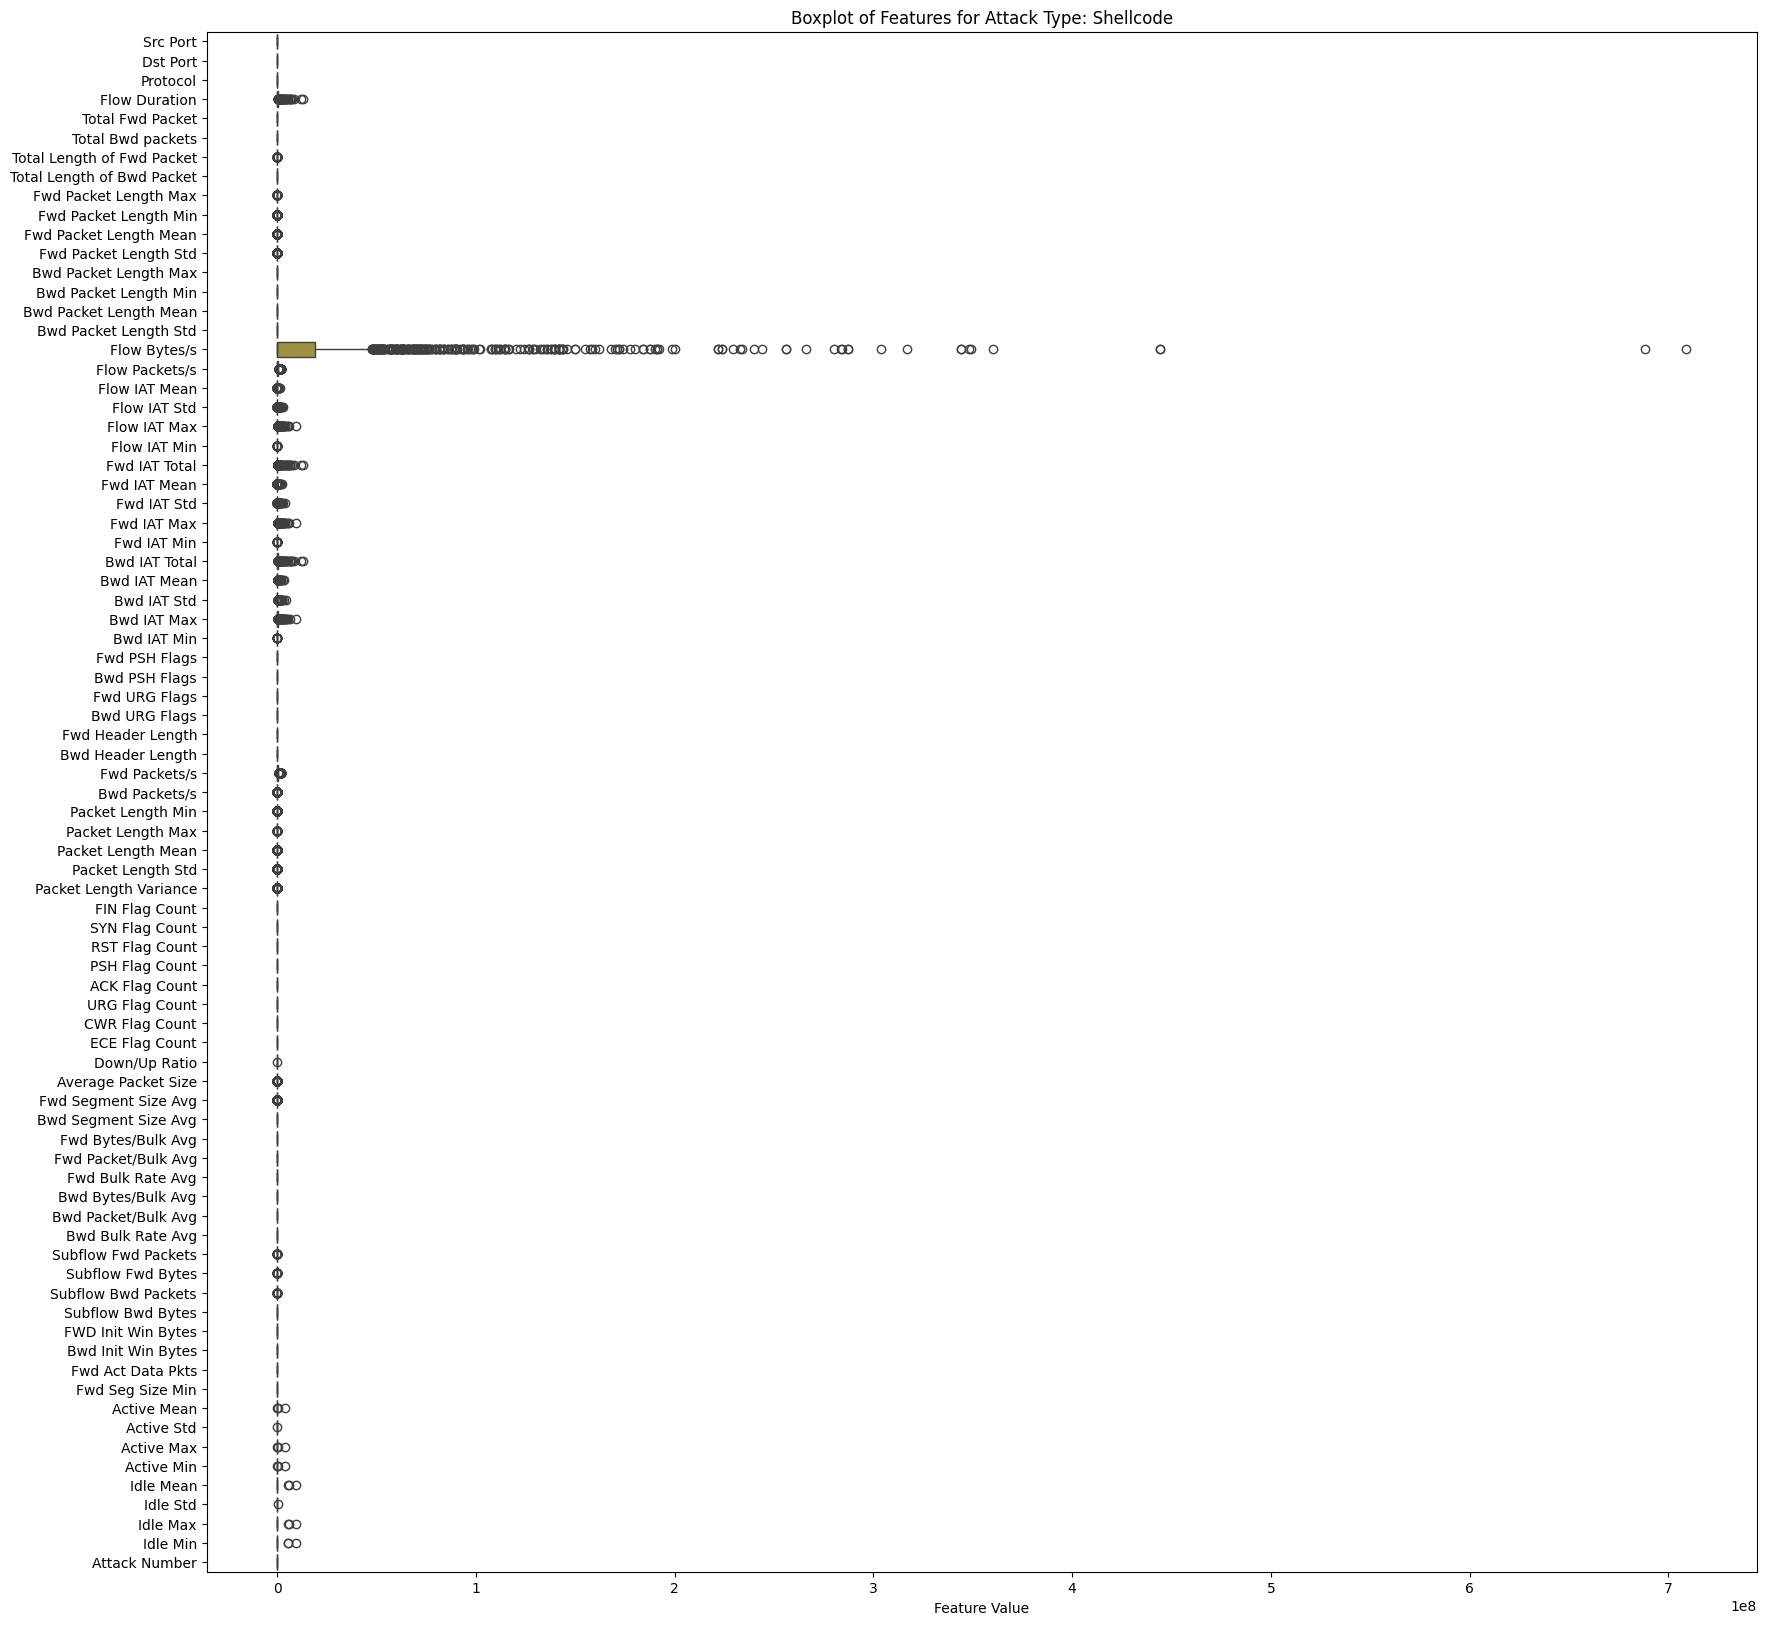

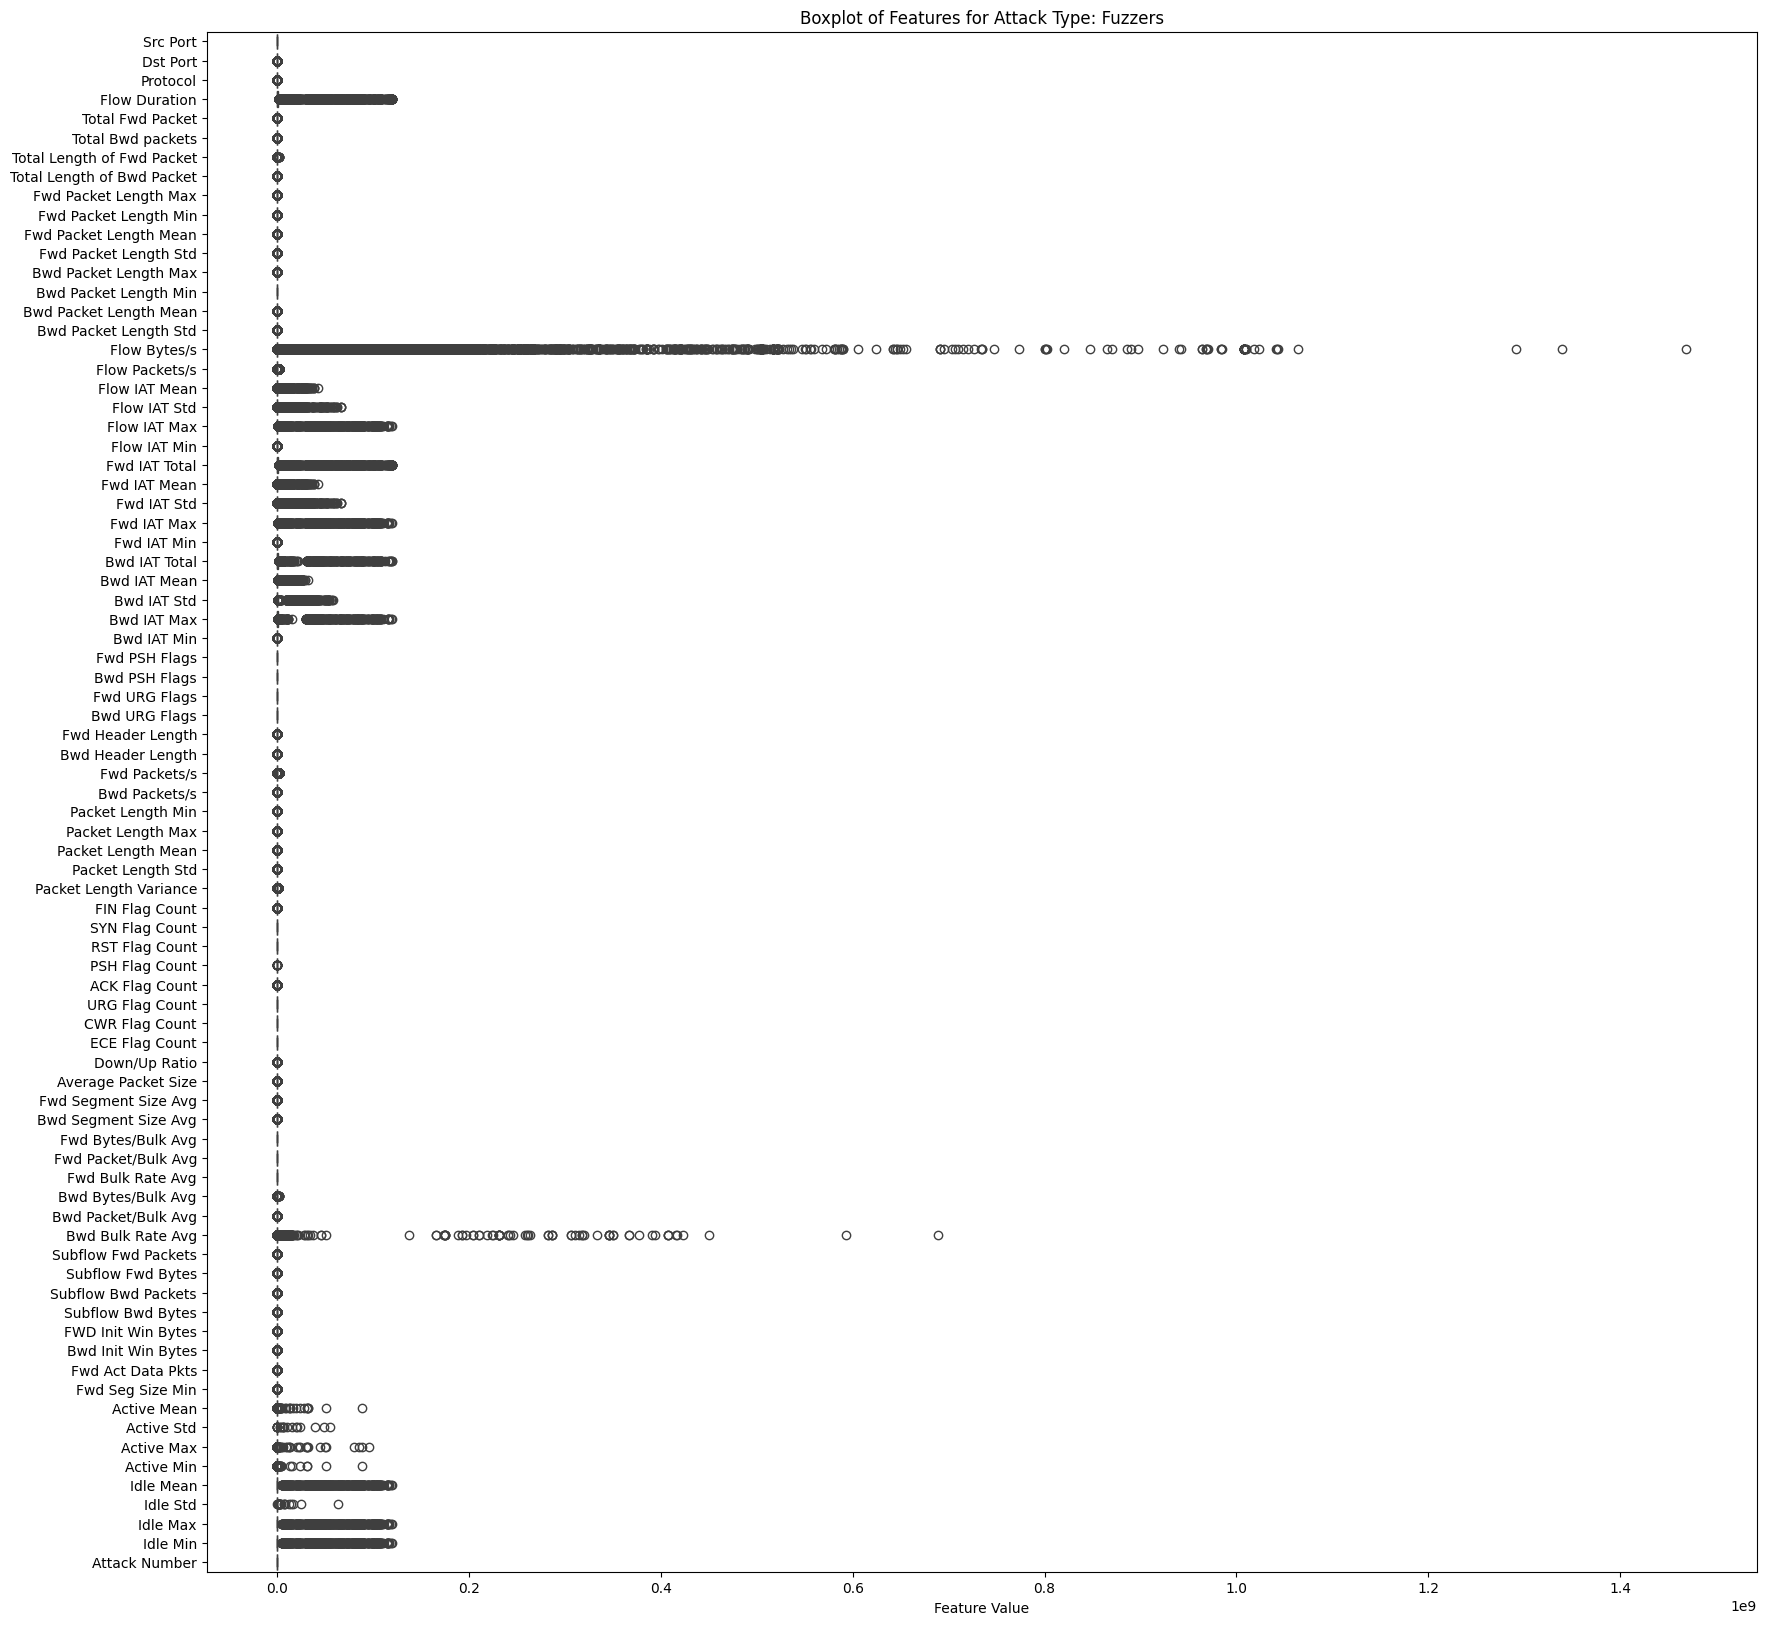

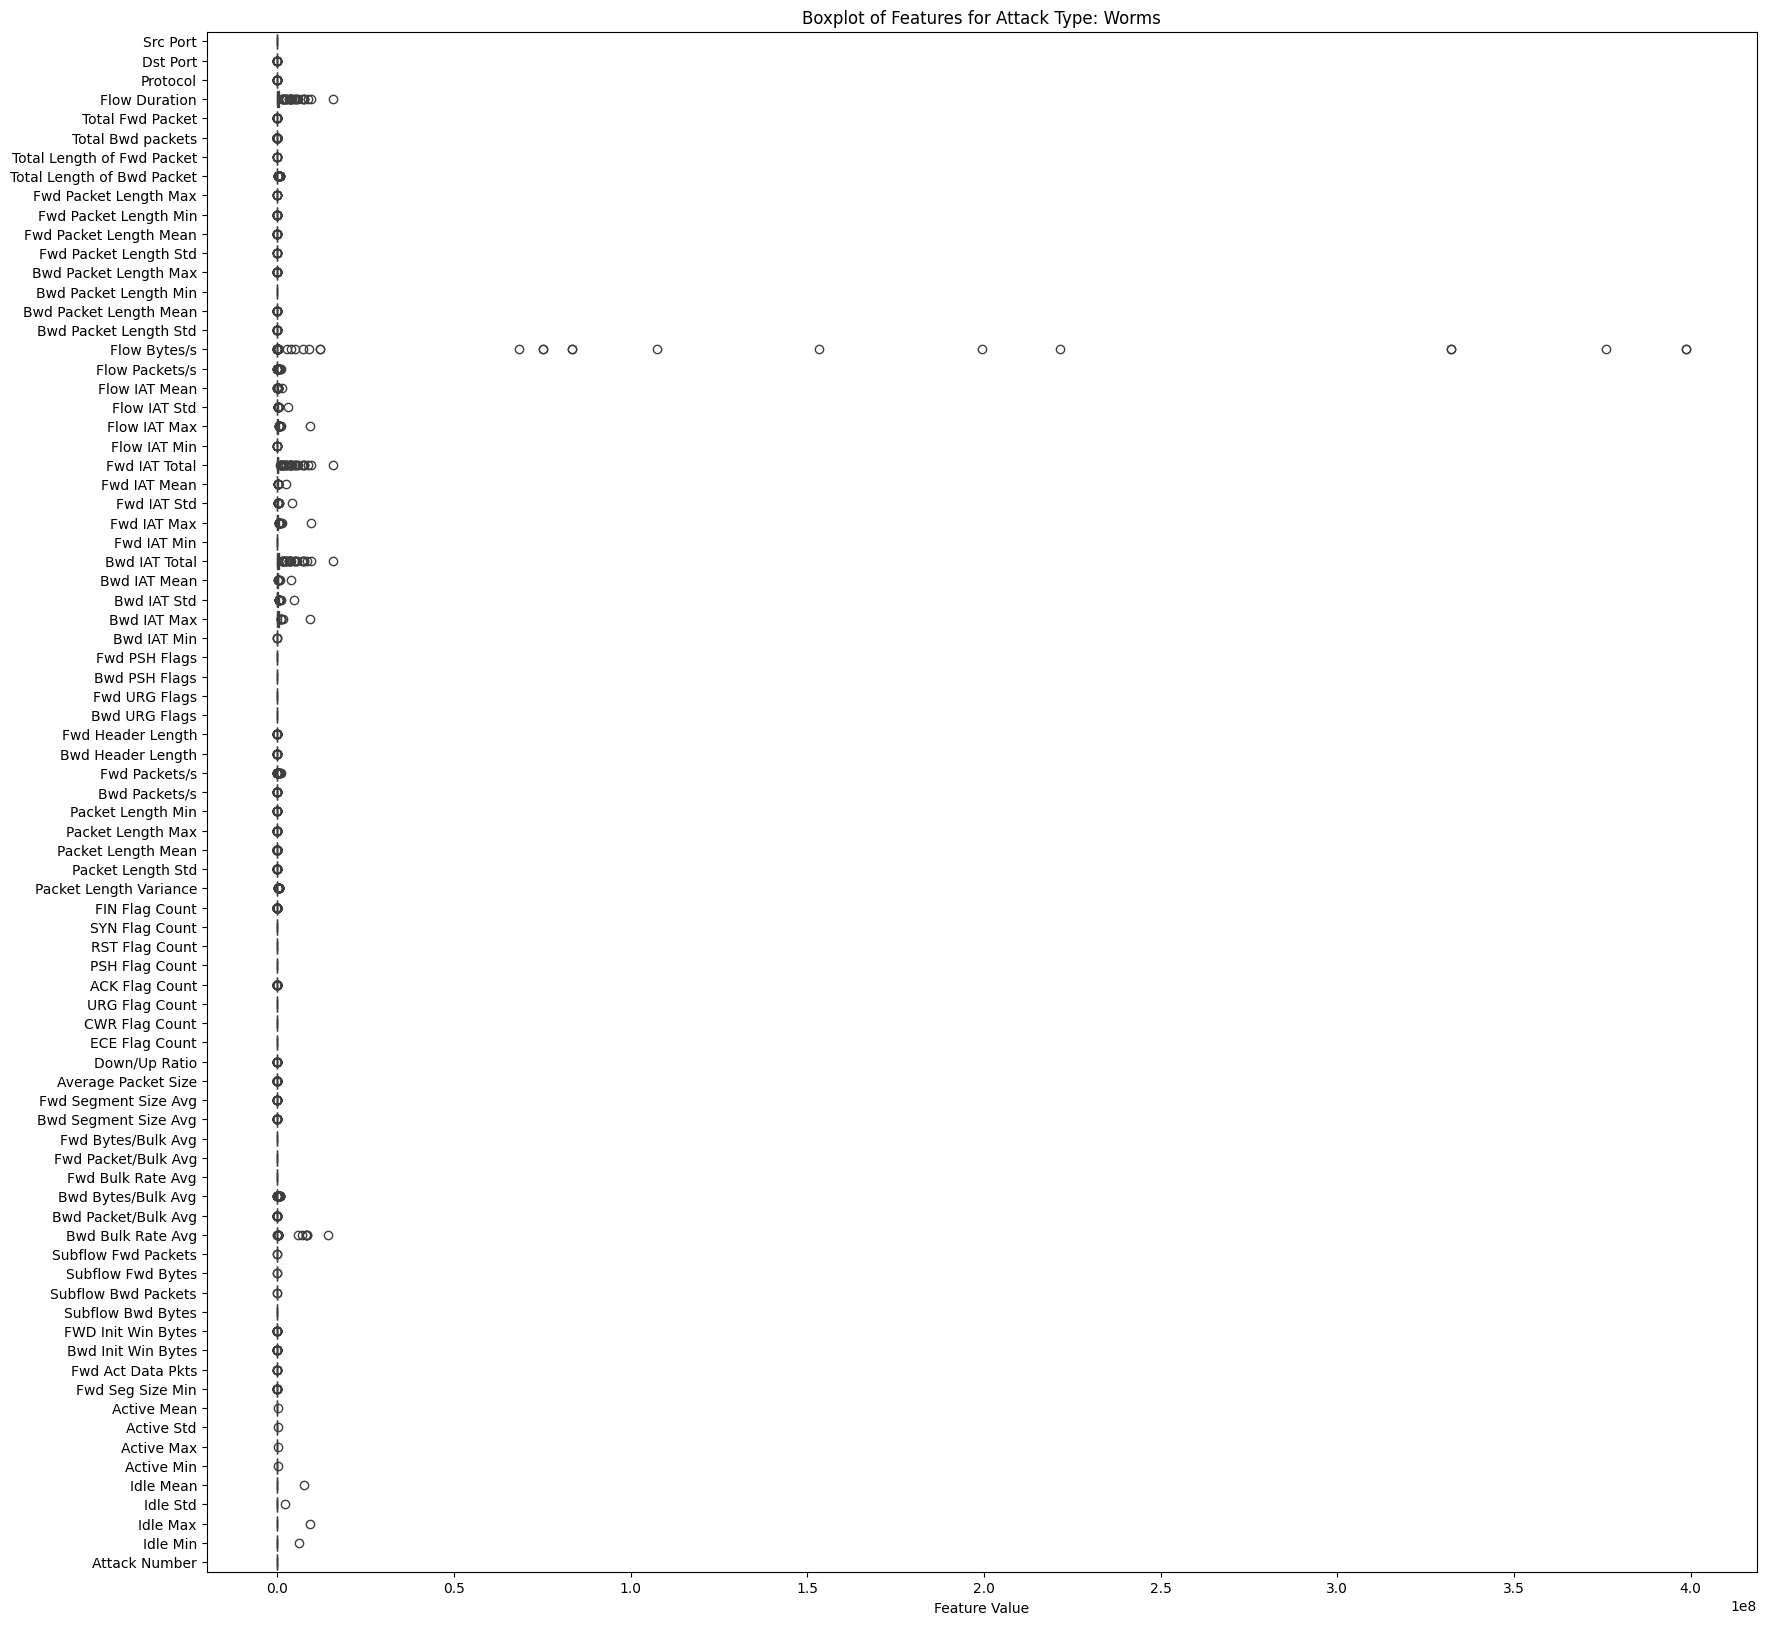

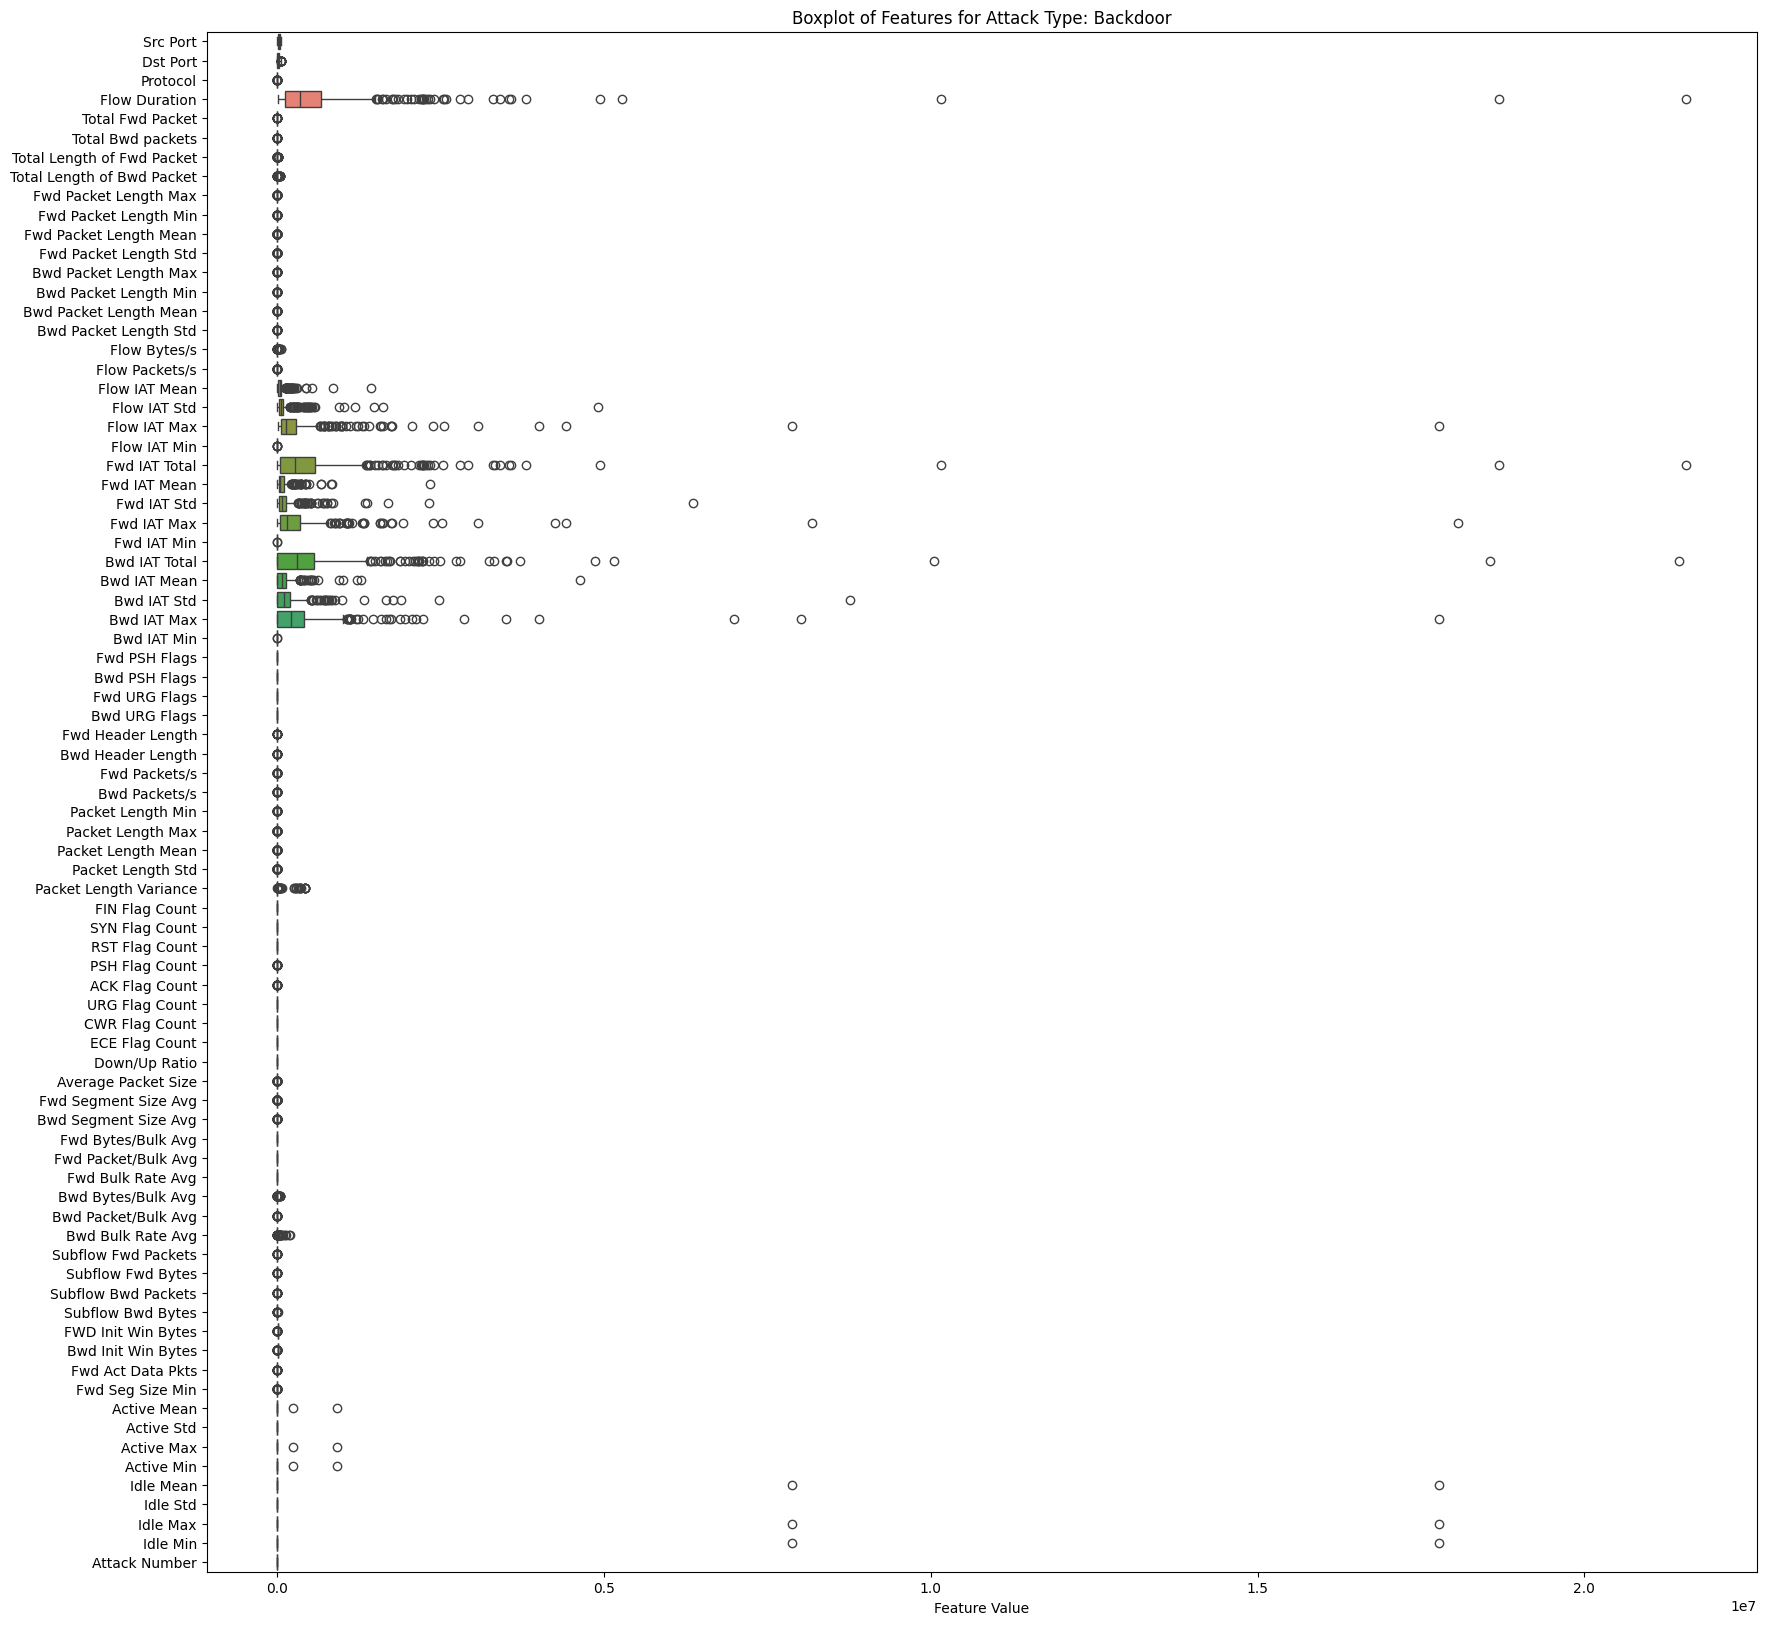

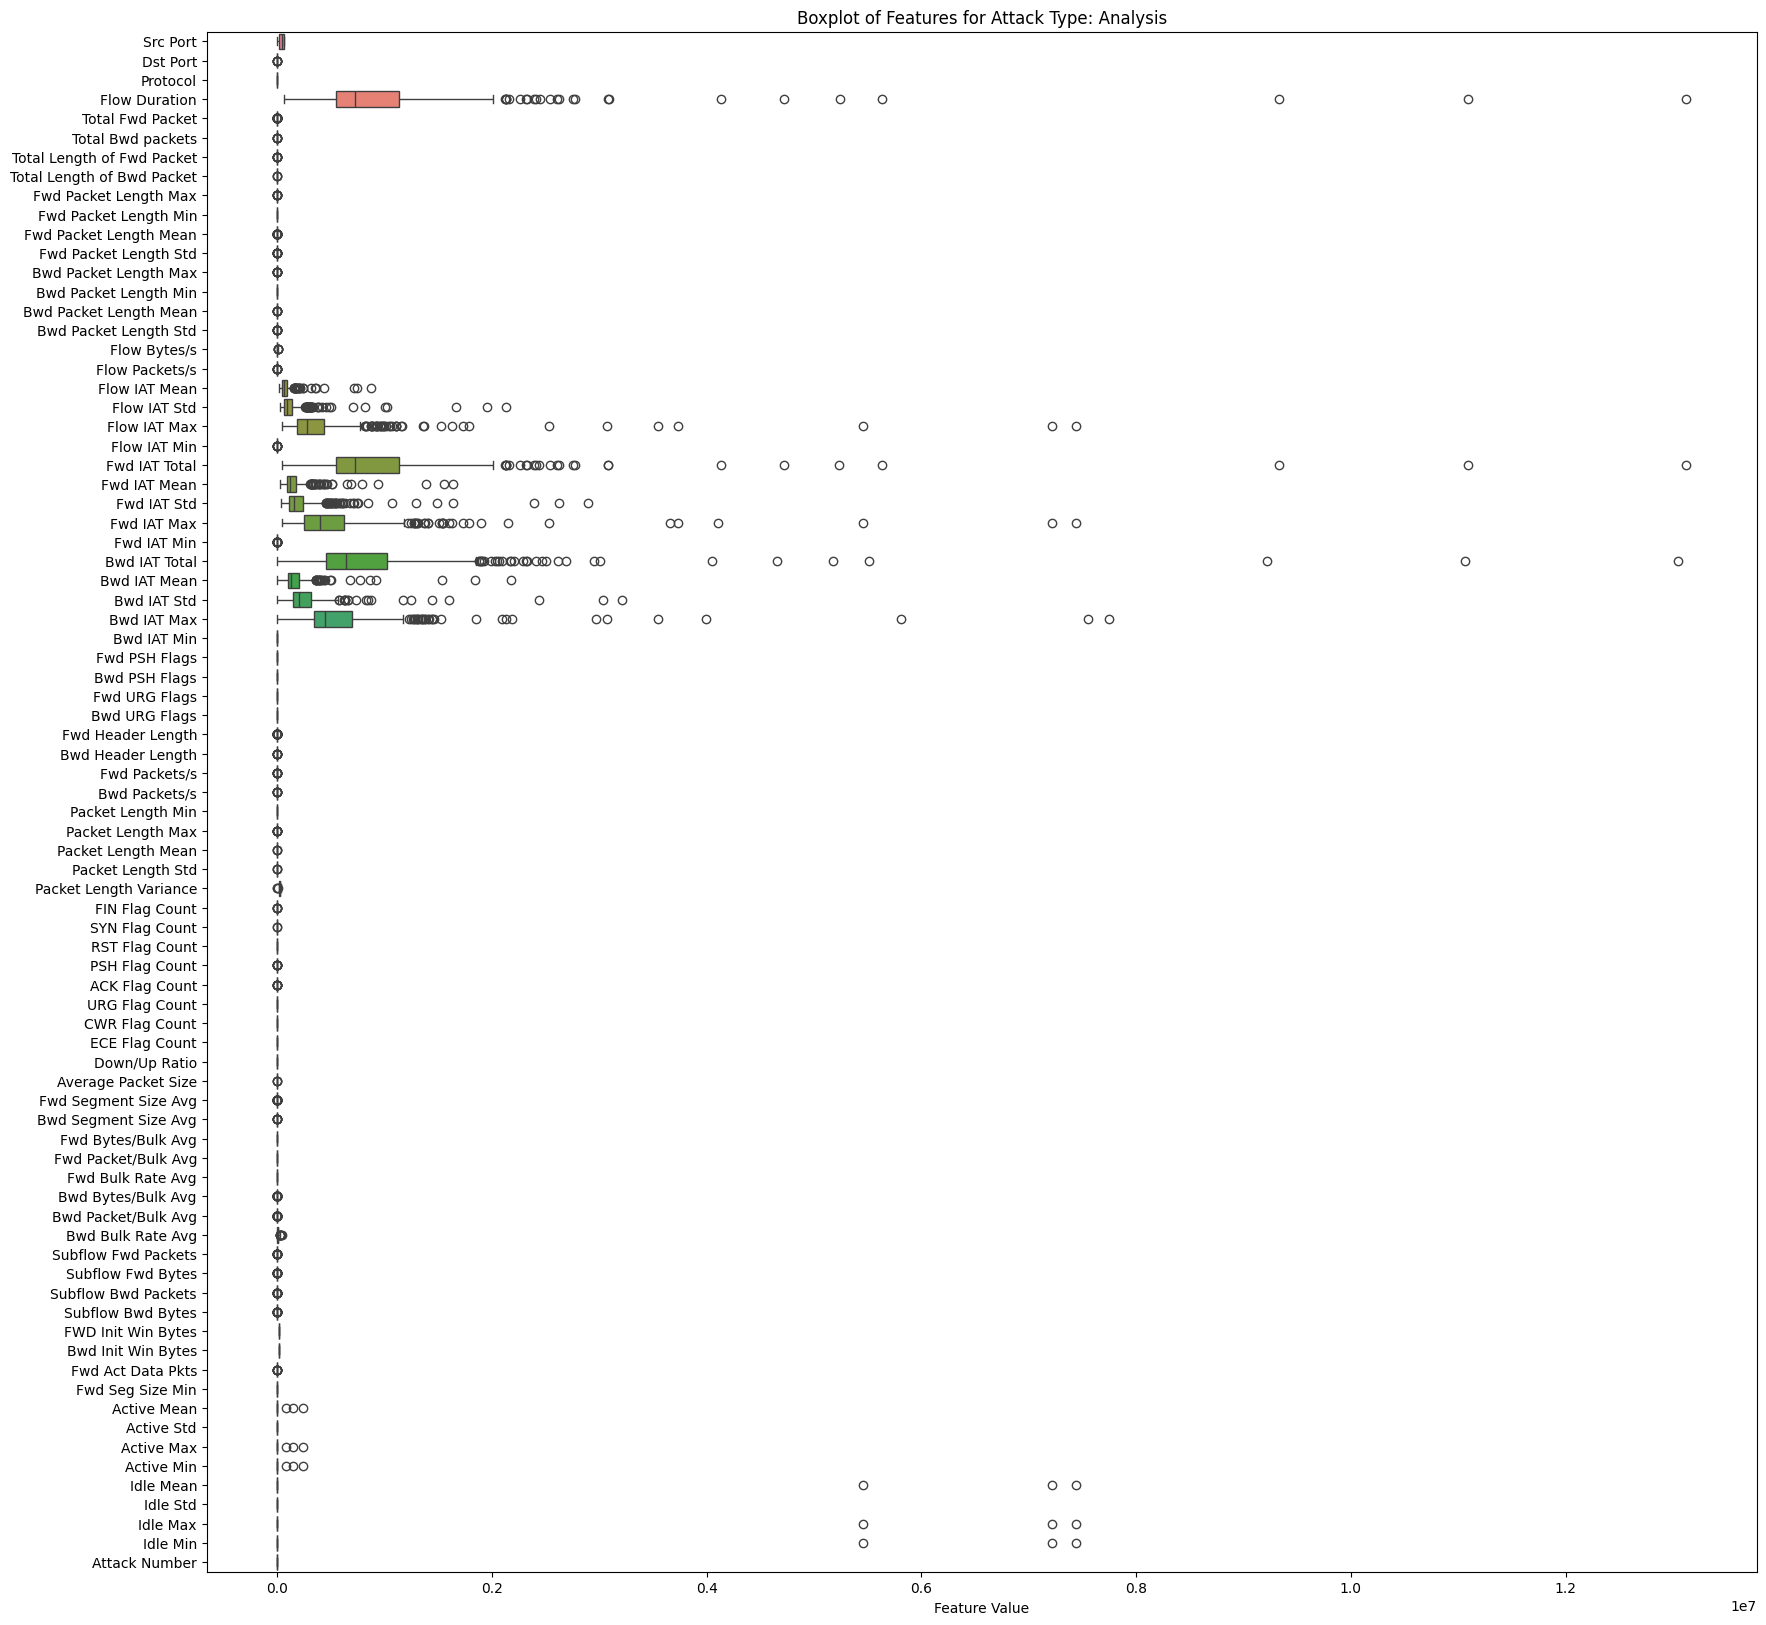

In [27]:
# Creating a boxplot for each attack type with the columns of sampled dataset
for attack_type in df['Attack Type'].unique():
    attack_data = df[df['Attack Type'] == attack_type]
    plt.figure(figsize=(20, 20))
    sns.boxplot(data = attack_data.drop(columns = ['Attack Type']), orient = 'h')
    plt.title(f'Boxplot of Features for Attack Type: {attack_type}')
    plt.xlabel('Feature Value')
    plt.show()

### 5. Data preprocessing

In [28]:
# For improving performance and reduce memory-related errors
old_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
        c_min = df[col].min()
        c_max = df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)

new_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

# Calculating percentage reduction in memory usage
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Initial memory usage: 2283.54 MB
Final memory usage: 1221.43 MB
Reduced memory usage: 46.51%


In [29]:
# Dropping columns with only one unique value
num_unique = df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = df[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count',
       'CWR Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg',
       'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg'],
      dtype='object')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3480335 entries, 0 to 3540240
Data columns (total 76 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Flow ID                     object 
 1   Src IP                      object 
 2   Src Port                    int32  
 3   Dst IP                      object 
 4   Dst Port                    int32  
 5   Protocol                    int32  
 6   Timestamp                   object 
 7   Flow Duration               int32  
 8   Total Fwd Packet            int32  
 9   Total Bwd packets           int32  
 10  Total Length of Fwd Packet  float32
 11  Total Length of Bwd Packet  float32
 12  Fwd Packet Length Max       float32
 13  Fwd Packet Length Min       float32
 14  Fwd Packet Length Mean      float32
 15  Fwd Packet Length Std       float32
 16  Bwd Packet Length Max       float32
 17  Bwd Packet Length Min       float32
 18  Bwd Packet Length Mean      float32
 19  Bwd Packet Length Std     

In [31]:
# save only numerical data
attacks = data['Attack Type']
data = data.select_dtypes(include = ['float32', 'int32'])

#### PCA

In [32]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

features = data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

transformed_features = ipca.transform(scaled_features)
new_data_pca = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data_pca['Attack Type'] = attacks.values

new_data_pca

information retained: 99.28%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Attack Type
0,4.348462,-2.643941,4.054311,-0.356901,-2.376156,0.398796,0.061841,1.393341,-0.195795,0.382214,...,-0.102270,-0.427338,0.379870,-0.502545,1.187051,1.692675,-0.497107,0.203105,0.546966,Exploits
1,1.492023,5.317196,1.830572,-0.128294,1.781223,-0.791588,1.055837,0.691023,-1.234631,1.139961,...,-0.483586,3.495337,0.351718,-0.910859,1.225136,-0.190789,0.062476,0.151345,-0.187572,Reconnaissance
2,2.397429,-1.557182,6.473838,3.210580,6.293459,0.723509,1.421475,-2.016155,0.191738,0.050193,...,0.028502,-0.144659,-0.008242,-0.190617,-0.546542,-0.712787,-0.075037,-0.057943,-0.369616,Exploits
3,-0.630173,0.355213,1.233188,0.578841,1.688755,0.140750,0.135229,-0.618152,-0.076933,0.293739,...,-0.114692,-0.008394,0.077184,0.095745,-0.231080,-0.247384,-0.202913,0.309214,-0.225563,DoS
4,-0.949187,0.701495,0.683528,0.625208,1.311139,0.184083,0.612701,0.371831,-0.230826,0.460531,...,0.045781,-0.134332,0.328683,0.262200,-0.448820,-0.719787,-0.166792,0.578406,-0.382903,Generic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3480330,1.273865,-0.640911,3.184099,1.693749,3.274108,0.334798,-0.068037,-1.602209,0.116595,0.003142,...,-0.233897,0.157007,0.050213,0.695763,-1.442948,-2.175880,-0.151470,1.104935,1.849130,Benign
3480331,-1.947942,0.721028,-1.565714,-2.739036,1.416390,0.034702,1.356255,0.071549,0.170351,-0.244659,...,0.110883,0.307980,0.069484,0.446030,-0.376313,0.709242,0.221878,0.316246,0.041928,Benign
3480332,-2.157992,0.799024,-1.289082,-1.602068,0.575953,-0.030656,0.525075,0.098961,0.061509,-0.168115,...,0.221000,-0.110775,0.004421,0.010261,0.250068,-0.460870,-0.184238,-0.163178,-0.023326,Benign
3480333,-2.053426,0.738502,-1.063350,-1.006568,0.275001,-0.039135,0.142135,-0.037288,0.014886,-0.081877,...,0.312459,-0.094163,-0.199818,-0.258239,-0.082745,0.062460,0.035431,-0.048221,0.036053,Benign


In [33]:
# select k best features
from sklearn.feature_selection import SelectKBest, f_classif

features = data
target = attacks

k = 20
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_20 = data[selected_features]
new_data_k_20['Attack Type'] = attacks.values

k = 40
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_40 = data[selected_features]
new_data_k_40['Attack Type'] = attacks.values

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/tmp/ipykernel_2705846/1773033171.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_20['Attack Type'] = attacks.values


Selected Features: Index(['Dst Port', 'Flow Duration', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Flow Bytes/s',
       'Flow Packets/s', 'Fwd IAT Total', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'FIN Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Fwd Segment Size Avg', 'Fwd Seg Size Min',
       'Active Mean', 'Active Std', 'Active Max', 'Attack Number'],
      dtype='object')
Selected Features: Index(['Dst Port', 'Flow Duration', 'Total Length of Fwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Packets/s', 'Bwd Packets/s',
    

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/tmp/ipykernel_2705846/1773033171.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_40['Attack Type'] = attacks.values
